# Publication maps — *Leucadendron argenteum*

This notebook contains only the five cartographic products requested for the
manuscript. The established layouts and visual encodings from the original
mapping notebook are retained: bathymetry, hypsometric elevation, administrative
boundaries, Table Mountain National Park, inset windows, standard viridis
probability colours, and the crossed colour × symbol encoding for sampled taxa.

Publication edits made here are deliberately limited to larger internal map
labels, tighter spacing between gradient scales and their titles, stable output
names, and use of the final rasters and validation occurrence layer generated
by the revised analytical notebooks.

**Run the analytical notebooks first.** Figures 8 and 9 read their probability
surface from the revised probability-mapping outputs rather than rebuilding it.


## Figure 1 — Occurrence of *Leucadendron argenteum*

Western Cape distribution map with GBIF occurrences, administrative land
polygons, Table Mountain National Park, bathymetry, named Cape Peninsula
localities, and the national locator inset. The map layout and colours are
unchanged from the preferred original version; internal labels are enlarged.


In [3]:
# =============================================================================
#  Distribution of Leucadendron argenteum across the Western Cape
#  Bathymetry + district land + TMNP + GBIF occurrences,
#  with a national locator inset and a combined legend.
# =============================================================================

## ---- 0. Packages ------------------------------------------------------------
pkgs <- c("terra", "sf", "marmap", "ggplot2", "tidyterra", "ggnewscale",
          "ggspatial", "ggforce", "ggtext", "patchwork", "scales", "ragg")
new  <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(new)) install.packages(new)
invisible(lapply(pkgs, library, character.only = TRUE))

sf::sf_use_s2(FALSE)
terra::terraOptions(memfrac = 0.7)

## ---- 1. USER INPUTS ---------------------------------------------------------
DISTRICT_PATH <- "Data/CPT/zaf_admin_boundaries/zaf_admin2.geojson"            # district polygons
COUNTRY_PATH  <- "Data/CPT/zaf_admin_boundaries/zaf_admin0.geojson"   # national outline (inset)
TMNP_PATH     <- "Data/Hyper/Phemelo_TMNP.shp"                    # Table Mountain NP

OCC_DIR       <- "untitled folder"                 # folder of .gpkg files
OCC_PATTERN   <- "\\.gpkg$"

OUT_PNG <- "Figure_1_L_argenteum_occurrence_distribution.png"
OUT_PDF <- "Figure_1_L_argenteum_occurrence_distribution.pdf"

XLIM <- c(18.000, 19.350)
YLIM <- c(-34.400, -33.440)

## ---- 2. Colours -------------------------------------------------------------
bathy_cols <- c("#5e24d6", "#22496d", "#042f66", "#054780", "#1074a6",
                "#218eb7", "#48b5d2", "#72d0e1", "#9ddee7", "#c6edec")
land_col  <- "#CCCCCC"
tmnp_fill <- "#B4D79E"
tmnp_line <- "#5F8B4C"

# Occurrence points: ColorBrewer PiYG magenta — the designed opposite of the
# park's green, and separable from it under red-green colour deficiency.
occ_fill  <- "#D01C8B"
sea_shallow <- tail(bathy_cols, 1)

# Point outline: ggplot's `stroke` is not points. 1 stroke unit ~= 1.417 pt,
# so this yields the requested 0.3 pt hairline outline.
OCC_STROKE <- 0.3 / 1.4173

## ---- 3. Vectors -------------------------------------------------------------
pad_bbox <- function(xlim, ylim, pad = 0.25)
  sf::st_bbox(c(xmin = xlim[1] - pad, xmax = xlim[2] + pad,
                ymin = ylim[1] - pad, ymax = ylim[2] + pad), crs = 4326)

districts <- sf::st_read(DISTRICT_PATH, quiet = TRUE) |>
  sf::st_transform(4326) |> sf::st_make_valid() |>
  sf::st_crop(pad_bbox(XLIM, YLIM))

country <- sf::st_read(COUNTRY_PATH, quiet = TRUE) |>
  sf::st_transform(4326) |> sf::st_make_valid()

tmnp <- sf::st_read(TMNP_PATH, quiet = TRUE) |>
  sf::st_transform(4326) |> sf::st_make_valid()

## -- Occurrences: one or more GeoPackages, every layer within each -----------
occ_files <- list.files(OCC_DIR, pattern = OCC_PATTERN, full.names = TRUE,
                        ignore.case = TRUE)
if (!length(occ_files))
  stop("No GeoPackages matched ", OCC_PATTERN, " in ", OCC_DIR)

read_occ <- function(f) {
  lyrs <- sf::st_layers(f)$name
  do.call(rbind, lapply(lyrs, function(l) {
    g <- sf::st_read(f, layer = l, quiet = TRUE) |> sf::st_transform(4326)
    g <- sf::st_geometry(g)
    if (!all(sf::st_geometry_type(g) %in% c("POINT", "MULTIPOINT")))
      g <- suppressWarnings(sf::st_centroid(g))     # polygons -> marker point
    sf::st_sf(src = paste0(basename(f), ":", l), geometry = g)
  }))
}

occ <- do.call(rbind, lapply(occ_files, read_occ))
occ <- occ[!duplicated(round(sf::st_coordinates(occ), 6)), ]   # drop repeats
occ <- sf::st_crop(occ, sf::st_bbox(c(xmin = XLIM[1], xmax = XLIM[2],
                                      ymin = YLIM[1], ymax = YLIM[2]),
                                    crs = 4326))
message("Loaded ", nrow(occ), " unique occurrence records from ",
        length(occ_files), " file(s)")

## ---- 4. Bathymetry ----------------------------------------------------------
bathy <- marmap::getNOAA.bathy(lon1 = XLIM[1] - 0.1, lon2 = XLIM[2] + 0.1,
                               lat1 = YLIM[1] - 0.1, lat2 = YLIM[2] + 0.1,
                               resolution = 0.25, keep = TRUE)
bathy_r <- terra::rast(marmap::as.raster(bathy))
names(bathy_r) <- "depth"
terra::crs(bathy_r) <- "EPSG:4326"

# Unclipped, land clamped to 0: the district polygons sit on top, so no white
# slivers appear where the coastline and the 15" grid disagree.
bathy_fill <- terra::clamp(bathy_r, upper = 0, values = TRUE)
DEPTH_MIN  <- as.numeric(terra::global(bathy_fill, "min", na.rm = TRUE)[1, 1])

## ---- 5. Helpers -------------------------------------------------------------
lab_lon <- function(x) paste0(formatC(abs(x), format = "f", digits = 3), "\u00b0",
                              ifelse(x < 0, "W", "E"))
lab_lat <- function(y) paste0(formatC(abs(y), format = "f", digits = 3), "\u00b0",
                              ifelse(y < 0, "S", "N"))

base_theme <- function(base_size = 12) {
  theme_bw(base_size = base_size) +
    theme(
      panel.grid   = element_line(colour = "grey50", linewidth = 0.2,
                                  linetype = "dotted"),
      panel.border = element_rect(colour = "black", linewidth = 0.6),
      axis.title   = element_text(face = "bold", size = rel(1.0)),
      axis.text    = element_text(colour = "black", size = rel(0.82),
                                  face = "bold"),
      axis.ticks   = element_line(colour = "black", linewidth = 0.4),
      plot.margin  = margin(4, 6, 4, 4)
    )
}

## ---- 6. Annotations ---------------------------------------------------------
# District name labels — edit to match your district field / positions
regions <- data.frame(
  label = c("West Coast", "City of Cape\nTown", "Cape\nWinelands", "Overberg"),
  x     = c(18.640, 18.400, 19.180, 19.100),
  y     = c(-33.470, -33.610, -33.760, -34.320)
)

# Locator circles and their boxed labels
sites <- data.frame(
  label = c("Lion's Head", "Devil's Peak", "Constantia", "Tokai",
            "Paarl", "Simonsberg", "Helderberg"),
  cx = c(18.398, 18.462, 18.420, 18.420, 18.940, 18.885, 18.868),
  cy = c(-33.942, -33.952, -34.020, -34.062, -33.755, -33.885, -34.078),
  r  = c(0.030, 0.030, 0.032, 0.030, 0.030, 0.038, 0.046),
  lx = c(18.160, 18.560, 18.110, 18.430, 18.820, 19.020, 19.030),
  ly = c(-33.895, -33.885, -34.030, -34.165, -33.620, -33.885, -34.100)
)

## ---- 7. Main map ------------------------------------------------------------
main <- ggplot() +
  geom_spatraster(data = bathy_fill, aes(fill = depth), maxcell = 3e6) +
  scale_fill_gradientn(colours = bathy_cols, limits = c(DEPTH_MIN, 0),
                       na.value = sea_shallow, guide = "none") +
  ggnewscale::new_scale_fill() +

  geom_sf(data = districts, fill = land_col, colour = "grey25",
          linewidth = 0.35) +
  geom_sf(data = tmnp, fill = tmnp_fill, colour = tmnp_line, linewidth = 0.3) +

  geom_sf(data = occ, shape = 21, size = 1.5, stroke = OCC_STROKE,
          fill = occ_fill, colour = "black") +

  geom_text(data = regions, aes(x, y, label = label), colour = "grey15",
            size = 4.0, lineheight = 0.95, fontface = "bold") +

  ggforce::geom_circle(data = sites, aes(x0 = cx, y0 = cy, r = r),
                       inherit.aes = FALSE, colour = "black", fill = NA,
                       linewidth = 0.45) +
  geom_segment(data = sites, aes(x = lx, y = ly, xend = cx, yend = cy),
               inherit.aes = FALSE, linewidth = 0.35) +
  geom_label(data = sites, aes(x = lx, y = ly, label = label),
             inherit.aes = FALSE, size = 3.8, fontface = "bold",
             fill = "white", label.size = 0.35,
             label.padding = unit(0.16, "lines")) +

  ggspatial::annotation_scale(location = "bl", width_hint = 0.3,
                              bar_cols = c("black", "white"), text_cex = 0.75,
                              height = unit(0.18, "cm"), line_width = 0.6) +
  ggspatial::annotation_north_arrow(
    location = "bl", which_north = "true", pad_y = unit(0.75, "cm"),
    height = unit(1.0, "cm"), width = unit(1.0, "cm"),
    style = north_arrow_fancy_orienteering(text_size = 7)) +

  coord_sf(xlim = XLIM, ylim = YLIM, expand = FALSE, crs = 4326) +
  scale_x_continuous(breaks = seq(18.00, 19.35, 0.15), labels = lab_lon) +
  scale_y_continuous(breaks = seq(-34.35, -33.45, 0.15), labels = lab_lat) +
  labs(x = "Longitude", y = "Latitude",
       title = "Distribution of *Leucadendron argenteum*<br>across the Western Cape") +
  base_theme(12) +
  theme(plot.title = ggtext::element_markdown(face = "bold", size = 14,
                                              hjust = 0.02, lineheight = 1.15,
                                              margin = margin(b = 6)))

## ---- 8. National locator inset ---------------------------------------------
sa_bb <- sf::st_bbox(country)
study_box <- sf::st_as_sfc(sf::st_bbox(c(xmin = XLIM[1], xmax = XLIM[2],
                                         ymin = YLIM[1], ymax = YLIM[2]),
                                       crs = 4326))

locator <- ggplot() +
  geom_sf(data = country, fill = land_col, colour = "grey25",
          linewidth = 0.3) +
  geom_sf(data = study_box, fill = NA, colour = "#D7191C", linewidth = 0.7) +
  coord_sf(xlim = c(sa_bb["xmin"] - 1.5, sa_bb["xmax"] + 1.5),
           ylim = c(sa_bb["ymin"] - 1.5, sa_bb["ymax"] + 1.5),
           expand = FALSE, crs = 4326) +
  theme_void() +
  theme(panel.background = element_rect(fill = "#7CC7DC", colour = NA),
        panel.border = element_rect(colour = "black", fill = NA,
                                    linewidth = 0.6),
        plot.margin = margin(2, 2, 2, 2))

## ---- 9. Legend and source panels -------------------------------------------
legend_panel <- local({
  n   <- 256
  BAR_TOP <- 8.55; BAR_BOT <- 4.75
  bar <- data.frame(y = seq(BAR_BOT, BAR_TOP, length.out = n))
  bar$val <- seq(DEPTH_MIN, 0, length.out = n)

  ggplot() +
    annotate("text", x = 0.35, y = 9.75, label = "Legend", hjust = 0,
             fontface = "bold", size = 5) +
    # bathymetry ramp — title sits directly on top of the bar
    annotate("text", x = 0.35, y = BAR_TOP + 0.35, label = "Bathymetry (m)",
             hjust = 0, vjust = 0, fontface = "bold", size = 3.5) +
    geom_raster(data = bar, aes(x = 0.85, y = y, fill = val)) +
    scale_fill_gradientn(colours = bathy_cols, guide = "none") +
    annotate("rect", xmin = 0.35, xmax = 1.35, ymin = BAR_BOT, ymax = BAR_TOP,
             fill = NA, colour = "black", linewidth = 0.35) +
    annotate("text", x = 1.55, y = BAR_TOP, hjust = 0, vjust = 1, size = 3.3,
             fontface = "bold", label = "0") +
    annotate("text", x = 1.55, y = BAR_BOT, hjust = 0, vjust = 0, size = 3.3,
             fontface = "bold", label = format(round(DEPTH_MIN), big.mark = " ")) +
    # occurrence marker
    annotate("point", x = 0.85, y = 3.75, shape = 21, size = 1.9,
             stroke = OCC_STROKE, fill = occ_fill, colour = "black") +
    ggtext::geom_richtext(aes(x = 1.55, y = 3.75,
                              label = "***Leucadendron argenteum***"),
                          hjust = 0, size = 3.3, label.colour = NA,
                          fill = NA, label.padding = unit(0, "pt")) +
    # park swatch
    annotate("rect", xmin = 0.35, xmax = 1.35, ymin = 2.15, ymax = 2.85,
             fill = tmnp_fill, colour = tmnp_line, linewidth = 0.4) +
    annotate("text", x = 1.55, y = 2.5, hjust = 0, size = 3.3,
             fontface = "bold", lineheight = 0.95,
             label = "Table Mountain\nNational Park") +
    scale_x_continuous(limits = c(0.1, 5.2), expand = c(0, 0)) +
    scale_y_continuous(limits = c(1.7, 10.3), expand = c(0, 0)) +
    theme_void() +
    theme(plot.background = element_rect(fill = "white", colour = "black",
                                         linewidth = 0.5),
          plot.margin = margin(8, 8, 8, 8))
})

source_panel <- ggplot() +
  ggtext::geom_richtext(
    aes(x = 0, y = c(1, 0),
        label = c("**Data source: *L. argenteum* occurrences (GBIF)**",
                  "**Global Bathymetry SRTM15+ V2.1**")),
    hjust = 0, size = 2.9, label.colour = NA, fill = NA,
    label.padding = unit(0, "pt")) +
  scale_x_continuous(limits = c(0, 5.6), expand = c(0, 0)) +
  scale_y_continuous(limits = c(-0.6, 1.6), expand = c(0, 0)) +
  theme_void() +
  theme(plot.background = element_rect(fill = "white", colour = "black",
                                       linewidth = 0.5),
        plot.margin = margin(8, 8, 8, 8))

## ---- 10. Assemble & export --------------------------------------------------
design <- "
AAB
AAC
AAD
AAE
"

fig <- patchwork::wrap_plots(
  A = main, B = locator, C = legend_panel, D = source_panel,
  E = patchwork::plot_spacer(),
  design  = design,
  widths  = c(1, 1, 0.52),
  heights = c(1, 1.15, 0.32, 0.43)
)

ggsave(OUT_PNG, fig, device = ragg::agg_png,
       width = 340, height = 235, units = "mm", dpi = 600, bg = "white")
ggsave(OUT_PDF, fig, device = cairo_pdf,
       width = 340, height = 235, units = "mm", bg = "white")

message("Written: ", normalizePath(OUT_PNG), " and ", normalizePath(OUT_PDF))

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
Loaded 1481 unique occurrence records from 1 file(s)

File already exists ; loading 'marmap_coord_17.9;-34.5;19.45;-33.34_res_0.25.csv'

Written: /Users/phemelo/Documents/LesHyperion/Figure_1_L_argenteum_occurrence_distribution.png and /Users/phemelo/Documents/LesHyperion/Figure_1_L_argenteum_occurrence_distribution.pdf



## Figure 2 — Seven study plots and elevation

Cape Peninsula field-site map with bathymetry, SRTM-derived elevation,
hillshade, Table Mountain National Park, and the Devil's Peak and Tokai plot
insets. Regional labels, inset labels and plot numbers are enlarged. The
elevation-scale title is placed immediately above its gradient.


In [6]:
# =============================================================================
# Figure 2 — Cape Peninsula field plots with elevation
# =============================================================================

## Packages -------------------------------------------------------------------
pkgs <- c(
  "terra", "sf", "marmap", "elevatr", "ggplot2", "tidyterra",
  "ggnewscale", "ggspatial", "ggforce", "shadowtext", "patchwork",
  "scales", "ragg"
)

new <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(new)) install.packages(new)
invisible(lapply(pkgs, library, character.only = TRUE))

sf::sf_use_s2(TRUE)
terra::terraOptions(memfrac = 0.7)

## User inputs ----------------------------------------------------------------
COUNTRY_PATH <- "Data/CPT/zaf_admin_boundaries/zaf_admin2.geojson"
TMNP_PATH <- "Data/Hyper/Phemelo_TMNP.shp"
SITES_DIR <- "Data/LiDAR/Sites"
SITES_PATTERN <- "\\.(geojson|json|shp|gpkg)$"
DISTRICT_PATH <- NA
SITE_ID_FROM <- "filename"

OUT_PNG <- "Figure_2_field_plots_elevation.png"
OUT_PDF <- "Figure_2_field_plots_elevation.pdf"

XLIM <- c(18.250, 19.050)
YLIM <- c(-34.430, -33.450)

DEM_ZOOM <- 12
INSET_ZOOM <- 14
PROJECTED_CRS <- 32734

ELEVATION_DIR <- "Data/Elevation"
dir.create(ELEVATION_DIR, recursive = TRUE, showWarnings = FALSE)

MAIN_DEM_PATH <- file.path(ELEVATION_DIR, "cape_peninsula_main_dem.tif")
DEVILS_DEM_PATH <- file.path(ELEVATION_DIR, "devils_peak_inset_dem.tif")
TOKAI_DEM_PATH <- file.path(ELEVATION_DIR, "tokai_inset_dem.tif")

## Colours --------------------------------------------------------------------
bathy_cols <- c(
  "#5e24d6", "#22496d", "#042f66", "#054780", "#1074a6",
  "#218eb7", "#48b5d2", "#72d0e1", "#9ddee7", "#c6edec"
)

elev_cols <- c(
  "#4C7A45", "#6F9B52", "#9DBB68", "#C6CE86", "#D9C58E",
  "#C9A26B", "#A97C4F", "#8A5B3C", "#7A5340", "#B9AEA6", "#EDE9E5"
)

plot_col <- "#B2182B"
tmnp_col <- "#111111"
sea_shallow <- tail(bathy_cols, 1)

## Bounding-box helper ---------------------------------------------------------
pad_bbox <- function(xlim, ylim, pad = 0.2) {
  sf::st_bbox(
    c(
      xmin = xlim[1] - pad,
      xmax = xlim[2] + pad,
      ymin = ylim[1] - pad,
      ymax = ylim[2] + pad
    ),
    crs = 4326
  )
}

## Vector data ----------------------------------------------------------------
land <- sf::st_read(COUNTRY_PATH, quiet = TRUE) |>
  sf::st_transform(4326) |>
  sf::st_make_valid() |>
  sf::st_crop(pad_bbox(XLIM, YLIM))

tmnp <- sf::st_read(TMNP_PATH, quiet = TRUE) |>
  sf::st_transform(4326) |>
  sf::st_make_valid()

## Study sites ----------------------------------------------------------------
site_files <- list.files(
  SITES_DIR,
  pattern = SITES_PATTERN,
  full.names = TRUE,
  ignore.case = TRUE
)

if (!length(site_files)) {
  stop("No site files matched ", SITES_PATTERN, " in ", SITES_DIR)
}

file_num <- suppressWarnings(
  as.numeric(
    gsub(
      "\\D",
      "",
      tools::file_path_sans_ext(basename(site_files))
    )
  )
)

file_order <- order(file_num, basename(site_files), na.last = TRUE)
site_files <- site_files[file_order]
file_num <- file_num[file_order]

read_site <- function(site_file, site_number) {
  site <- sf::st_read(site_file, quiet = TRUE) |>
    sf::st_make_valid()

  if (SITE_ID_FROM == "filename" && !is.na(file_num[site_number])) {
    plot_id <- as.character(file_num[site_number])
  } else if (SITE_ID_FROM %in% names(site)) {
    plot_id <- as.character(site[[SITE_ID_FROM]][1])
  } else {
    plot_id <- as.character(site_number)
  }

  geometry_type <- sf::st_geometry_type(site)

  if (!all(geometry_type %in% c("POINT", "MULTIPOINT")) || nrow(site) > 1) {
    site_projected <- sf::st_transform(site, PROJECTED_CRS)
    site_centroid <- sf::st_centroid(sf::st_union(site_projected))

    site <- sf::st_sf(
      geometry = site_centroid,
      crs = PROJECTED_CRS
    ) |>
      sf::st_transform(4326)
  } else {
    site <- sf::st_transform(site, 4326)
  }

  sf::st_sf(
    plot_id = plot_id,
    source_file = basename(site_file),
    geometry = sf::st_geometry(site)
  )
}

sites <- do.call(
  rbind,
  Map(read_site, site_files, seq_along(site_files))
)

sites <- sites[order(as.numeric(sites$plot_id)), ]

message(
  "Loaded ", nrow(sites), " plots: ",
  paste(sites$plot_id, collapse = ", ")
)

sites_xy <- cbind(
  sites,
  sf::st_coordinates(sites)
)

## Optional district boundaries -----------------------------------------------
districts <- if (!is.na(DISTRICT_PATH)) {
  sf::st_read(DISTRICT_PATH, quiet = TRUE) |>
    sf::st_transform(4326) |>
    sf::st_crop(pad_bbox(XLIM, YLIM))
} else {
  NULL
}

## Region labels ---------------------------------------------------------------
regions <- data.frame(
  label = c(
    "West Coast",
    "City of\nCape Town",
    "Cape\nWinelands",
    "Overberg"
  ),
  x = c(18.630, 18.440, 18.900, 18.950),
  y = c(-33.490, -33.770, -33.830, -34.300)
)

## Bathymetry -----------------------------------------------------------------
bathy <- marmap::getNOAA.bathy(
  lon1 = XLIM[1] - 0.1,
  lon2 = XLIM[2] + 0.1,
  lat1 = YLIM[1] - 0.1,
  lat2 = YLIM[2] + 0.1,
  resolution = 0.25,
  keep = TRUE
)

bathy_r <- terra::rast(marmap::as.raster(bathy))
names(bathy_r) <- "depth"
terra::crs(bathy_r) <- "EPSG:4326"

bathy_fill <- terra::clamp(
  bathy_r,
  upper = 0,
  values = TRUE
)

DEPTH_MIN <- as.numeric(
  terra::global(bathy_fill, "min", na.rm = TRUE)[1, 1]
)

## Cached elevation ------------------------------------------------------------
get_cached_dem <- function(xlim, ylim, zoom, cache_path) {
  if (file.exists(cache_path)) {
    message("Using cached elevation raster: ", cache_path)

    dem <- terra::rast(cache_path)
    names(dem) <- "elev"

    return(dem)
  }

  message("Downloading elevation raster: ", cache_path)

  bb <- sf::st_bbox(
    c(
      xmin = xlim[1],
      xmax = xlim[2],
      ymin = ylim[1],
      ymax = ylim[2]
    ),
    crs = 4326
  )

  bb <- sf::st_as_sf(
    sf::st_as_sfc(bb)
  )

  dem <- elevatr::get_elev_raster(
    locations = bb,
    z = zoom,
    clip = "bbox",
    verbose = TRUE
  ) |>
    terra::rast()

  names(dem) <- "elev"

  terra::writeRaster(
    dem,
    cache_path,
    overwrite = TRUE
  )

  message("Saved elevation raster: ", cache_path)

  dem
}

dem <- get_cached_dem(
  XLIM,
  YLIM,
  DEM_ZOOM,
  MAIN_DEM_PATH
)

dem_land <- terra::mask(
  dem,
  terra::vect(land)
)

dem_land[dem_land < 1] <- NA

ELEV_MAX <- as.numeric(
  terra::global(dem_land, "max", na.rm = TRUE)[1, 1]
)

## Hillshade ------------------------------------------------------------------
make_hillshade <- function(raster) {
  slope <- terra::terrain(
    raster,
    "slope",
    unit = "radians"
  )

  aspect <- terra::terrain(
    raster,
    "aspect",
    unit = "radians"
  )

  hillshade <- terra::shade(
    slope,
    aspect,
    angle = 40,
    direction = 315
  )

  names(hillshade) <- "hs"

  hillshade
}

hill <- terra::mask(
  make_hillshade(dem),
  terra::vect(land)
)

## Axis labels ----------------------------------------------------------------
lab_lon <- function(x) {
  paste0(
    formatC(abs(x), format = "f", digits = 3),
    "\u00b0",
    ifelse(x < 0, "W", "E")
  )
}

lab_lat <- function(y) {
  paste0(
    formatC(abs(y), format = "f", digits = 3),
    "\u00b0",
    ifelse(y < 0, "S", "N")
  )
}

## Plot theme -----------------------------------------------------------------
base_theme <- function(base_size = 11) {
  theme_bw(base_size = base_size) +
    theme(
      panel.grid = element_line(
        colour = "grey55",
        linewidth = 0.2,
        linetype = "dotted"
      ),
      panel.border = element_rect(
        colour = "black",
        linewidth = 0.6
      ),
      axis.title = element_text(
        face = "bold",
        size = rel(1)
      ),
      axis.text = element_text(
        colour = "black",
        size = rel(0.82)
      ),
      axis.ticks = element_line(
        colour = "black",
        linewidth = 0.4
      ),
      plot.title = element_text(
        face = "bold",
        hjust = 0.5,
        size = rel(1.05)
      ),
      plot.margin = margin(4, 6, 4, 4)
    )
}

elev_scale <- function() {
  scale_fill_gradientn(
    colours = elev_cols,
    limits = c(0, ELEV_MAX),
    na.value = "transparent",
    guide = "none"
  )
}

park_layers <- function(line_width = 0.75) {
  list(
    geom_sf(
      data = tmnp,
      fill = NA,
      colour = alpha("white", 0.85),
      linewidth = line_width * 2.2
    ),
    geom_sf(
      data = tmnp,
      fill = NA,
      colour = tmnp_col,
      linewidth = line_width,
      linetype = "22"
    )
  )
}

## Insets ---------------------------------------------------------------------
insets <- data.frame(
  name = c(
    "Devil's Peak plots (1\u20135)",
    "Tokai Region plots (6\u20137)"
  ),
  key = c(
    "Plots 1\u20135",
    "Plots 6\u20137"
  ),
  xmin = c(18.4525, 18.4155),
  xmax = c(18.4595, 18.4215),
  ymin = c(-33.9525, -34.0062),
  ymax = c(-33.9465, -34.0012),
  lx = c(18.560, 18.600),
  ly = c(-33.905, -34.040),
  stringsAsFactors = FALSE
)

insets$cx <- (insets$xmin + insets$xmax) / 2
insets$cy <- (insets$ymin + insets$ymax) / 2
insets$r <- 0.030

## Main map -------------------------------------------------------------------
main <- ggplot() +
  geom_spatraster(
    data = bathy_fill,
    aes(fill = depth),
    maxcell = 2e6
  ) +
  scale_fill_gradientn(
    colours = bathy_cols,
    limits = c(DEPTH_MIN, 0),
    na.value = sea_shallow,
    guide = "none"
  ) +
  ggnewscale::new_scale_fill() +

  geom_spatraster(
    data = hill,
    aes(fill = hs),
    maxcell = 6e6,
    show.legend = FALSE
  ) +
  scale_fill_gradientn(
    colours = grey(0:100 / 100),
    na.value = "transparent",
    guide = "none"
  ) +
  ggnewscale::new_scale_fill() +

  geom_spatraster(
    data = dem_land,
    aes(fill = elev),
    maxcell = 6e6,
    alpha = 0.78
  ) +
  elev_scale() +

  {
    if (!is.null(districts)) {
      geom_sf(
        data = districts,
        fill = NA,
        colour = "grey10",
        linewidth = 0.35
      )
    }
  } +

  geom_sf(
    data = land,
    fill = NA,
    colour = "grey20",
    linewidth = 0.3
  ) +

  park_layers(line_width = 0.5) +

  shadowtext::geom_shadowtext(
    data = regions,
    aes(x, y, label = label),
    colour = "grey10",
    bg.colour = "white",
    bg.r = 0.16,
    size = 4,
    lineheight = 0.95,
    fontface = "plain"
  ) +

  ggforce::geom_circle(
    data = insets,
    aes(x0 = cx, y0 = cy, r = r),
    inherit.aes = FALSE,
    colour = "black",
    fill = NA,
    linewidth = 0.5
  ) +

  geom_segment(
    data = insets,
    aes(
      x = lx,
      y = ly,
      xend = cx,
      yend = cy
    ),
    inherit.aes = FALSE,
    linewidth = 0.35
  ) +

  geom_label(
    data = insets,
    aes(
      x = lx,
      y = ly,
      label = key
    ),
    inherit.aes = FALSE,
    size = 3.8,
    fontface = "bold",
    fill = "white",
    label.size = 0.35,
    label.padding = unit(0.16, "lines")
  ) +

  ggspatial::annotation_scale(
    location = "bl",
    width_hint = 0.3,
    bar_cols = c("black", "white"),
    text_cex = 0.75,
    height = unit(0.18, "cm"),
    line_width = 0.6
  ) +

  ggspatial::annotation_north_arrow(
    location = "bl",
    which_north = "true",
    pad_y = unit(0.75, "cm"),
    height = unit(0.9, "cm"),
    width = unit(0.9, "cm"),
    style = north_arrow_fancy_orienteering(
      text_size = 7
    )
  ) +

  coord_sf(
    xlim = XLIM,
    ylim = YLIM,
    expand = FALSE,
    crs = 4326
  ) +

  scale_x_continuous(
    breaks = seq(18.3, 19.0, 0.1),
    labels = lab_lon
  ) +

  scale_y_continuous(
    breaks = seq(-34.4, -33.5, 0.1),
    labels = lab_lat
  ) +

  labs(
    x = "Longitude",
    y = "Latitude"
  ) +

  base_theme(12)

## Inset DEMs -----------------------------------------------------------------
devils_dem <- get_cached_dem(
  c(insets$xmin[1], insets$xmax[1]),
  c(insets$ymin[1], insets$ymax[1]),
  INSET_ZOOM,
  DEVILS_DEM_PATH
)

tokai_dem <- get_cached_dem(
  c(insets$xmin[2], insets$xmax[2]),
  c(insets$ymin[2], insets$ymax[2]),
  INSET_ZOOM,
  TOKAI_DEM_PATH
)

## Inset builder ---------------------------------------------------------------
make_inset <- function(inset_number, elevation_raster, arrow_position = "bl") {
  bb <- insets[inset_number, ]

  x_limits <- c(
    bb$xmin,
    bb$xmax
  )

  y_limits <- c(
    bb$ymin,
    bb$ymax
  )

  elevation_raster <- terra::disagg(
    elevation_raster,
    4,
    method = "bilinear"
  )

  inset_hillshade <- make_hillshade(
    elevation_raster
  )

  points <- sites_xy[
    sites_xy$X >= x_limits[1] &
      sites_xy$X <= x_limits[2] &
      sites_xy$Y >= y_limits[1] &
      sites_xy$Y <= y_limits[2],
  ]

  ggplot() +
    geom_spatraster(
      data = inset_hillshade,
      aes(fill = hs),
      maxcell = Inf,
      show.legend = FALSE
    ) +

    scale_fill_gradientn(
      colours = grey(0:100 / 100),
      guide = "none",
      na.value = "transparent"
    ) +

    ggnewscale::new_scale_fill() +

    geom_spatraster(
      data = elevation_raster,
      aes(fill = elev),
      maxcell = Inf,
      alpha = 0.8
    ) +

    elev_scale() +

    park_layers(
      line_width = 0.6
    ) +

    geom_sf(
      data = points,
      shape = 23,
      size = 2.4,
      stroke = 0.5,
      fill = plot_col,
      colour = "black"
    ) +

    shadowtext::geom_shadowtext(
      data = points,
      aes(
        X,
        Y,
        label = plot_id
      ),
      nudge_y = diff(y_limits) * 0.055,
      size = 3.8,
      fontface = "bold",
      colour = "black",
      bg.colour = "white",
      bg.r = 0.2
    ) +

    ggspatial::annotation_scale(
      location = "br",
      width_hint = 0.35,
      bar_cols = c("black", "white"),
      text_cex = 0.7,
      height = unit(0.15, "cm"),
      line_width = 0.5
    ) +

    ggspatial::annotation_north_arrow(
      location = arrow_position,
      which_north = "true",
      height = unit(0.65, "cm"),
      width = unit(0.65, "cm"),
      style = north_arrow_fancy_orienteering(
        text_size = 6
      )
    ) +

    coord_sf(
      xlim = x_limits,
      ylim = y_limits,
      expand = FALSE,
      crs = 4326
    ) +

    scale_x_continuous(
      breaks = scales::breaks_pretty(4),
      labels = lab_lon
    ) +

    scale_y_continuous(
      breaks = scales::breaks_pretty(4),
      labels = lab_lat
    ) +

    labs(
      title = bb$name,
      x = NULL,
      y = NULL
    ) +

    base_theme(10)
}

p_devil <- make_inset(
  1,
  devils_dem,
  arrow_position = "bl"
)

p_tokai <- make_inset(
  2,
  tokai_dem,
  arrow_position = "tl"
)

## Legend ---------------------------------------------------------------------
legend_panel <- local({
  n <- 256

  bar <- data.frame(
    y = seq(
      0,
      5.2,
      length.out = n
    )
  )

  bar$val <- seq(
    0,
    ELEV_MAX,
    length.out = n
  )

  ggplot() +
    annotate(
      "text",
      x = 0.4,
      y = 9.5,
      label = "Legend",
      hjust = 0,
      fontface = "bold",
      size = 5
    ) +

    annotate(
      "point",
      x = 0.85,
      y = 8.5,
      shape = 23,
      size = 2.6,
      stroke = 0.5,
      fill = plot_col,
      colour = "black"
    ) +

    annotate(
      "text",
      x = 1.6,
      y = 8.5,
      label = "Field plots",
      hjust = 0,
      size = 3.4
    ) +

    annotate(
      "rect",
      xmin = 0.45,
      xmax = 1.25,
      ymin = 7.25,
      ymax = 7.75,
      fill = "white",
      colour = tmnp_col,
      linewidth = 0.5,
      linetype = "22"
    ) +

    annotate(
      "text",
      x = 1.6,
      y = 7.5,
      label = "Table Mountain\nNational Park",
      hjust = 0,
      size = 3.4,
      lineheight = 0.95
    ) +

    annotate(
      "text",
      x = 0.4,
      y = 5.55,
      label = "Elevation (m)",
      hjust = 0,
      fontface = "bold",
      size = 3.6
    ) +

    geom_raster(
      data = bar,
      aes(
        x = 0.9,
        y = y,
        fill = val
      )
    ) +

    scale_fill_gradientn(
      colours = elev_cols,
      guide = "none"
    ) +

    annotate(
      "rect",
      xmin = 0.4,
      xmax = 1.4,
      ymin = 0,
      ymax = 5.2,
      fill = NA,
      colour = "black",
      linewidth = 0.35
    ) +

    annotate(
      "text",
      x = 1.6,
      y = 5.2,
      label = format(
        round(ELEV_MAX),
        big.mark = " "
      ),
      hjust = 0,
      vjust = 1,
      size = 3.3
    ) +

    annotate(
      "text",
      x = 1.6,
      y = 0,
      label = "0",
      hjust = 0,
      vjust = 0,
      size = 3.3
    ) +

    scale_x_continuous(
      limits = c(0.2, 4.6),
      expand = c(0, 0)
    ) +

    scale_y_continuous(
      limits = c(-0.4, 10.2),
      expand = c(0, 0)
    ) +

    theme_void() +

    theme(
      plot.background = element_rect(
        fill = "white",
        colour = "black",
        linewidth = 0.5
      ),
      plot.margin = margin(6, 10, 8, 10)
    )
})

## Assemble -------------------------------------------------------------------
design <- "
AABD
AACD
"

figure_2 <- patchwork::wrap_plots(
  A = main,
  B = p_devil,
  C = p_tokai,
  D = legend_panel,
  design = design,
  widths = c(
    1,
    1,
    1.02,
    0.44
  )
)

## Export ---------------------------------------------------------------------
ggsave(
  OUT_PNG,
  figure_2,
  device = ragg::agg_png,
  width = 380,
  height = 250,
  units = "mm",
  dpi = 600,
  bg = "white"
)

ggsave(
  OUT_PDF,
  figure_2,
  device = cairo_pdf,
  width = 380,
  height = 250,
  units = "mm",
  bg = "white"
)

message(
  "Written: ",
  normalizePath(OUT_PNG),
  " and ",
  normalizePath(OUT_PDF)
)

Spherical geometry (s2) switched on

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
Loaded 7 plots: 1, 2, 3, 4, 5, 6, 7

File already exists ; loading 'marmap_coord_18.15;-34.53;19.15;-33.35_res_0.25.csv'


Mosaicing & Projecting

Clipping DEM to bbox

Note: Elevation units are in meters.

Saved elevation raster: Data/Elevation/cape_peninsula_main_dem.tif

<SpatRaster> resampled to 6004614 cells.
<SpatRaster> resampled to 6004614 cells.

Mosaicing & Projecting

Clipping DEM to bbox

Note: Elevation units are in meters.

Saved elevation raster: Data/Elevation/devils_peak_inset_dem.tif


Mosaicing & Projecting

Clipping DEM to bbox

Note: Elevation units are in meters.

Saved elevation raster: Data/Elevation/tokai_inset_dem.tif

Written: /Users/phemelo/Documents/LesHyperion/Figure_2_field_plots_elevation.png and /Users/phemelo/Documents/LesHyperion/Figure_2_field_plots_elevation.pdf



## Figure 8 — Structurally filtered probability map

This figure reads the final AVIRIS-NG + LVIS structurally filtered probability
raster generated by the revised probability-mapping notebook:

`outputs/03_probability_mapping_validation/rasters/Larg_probability_TMNP_AVIRIS_LVIS_RH98_filtered.tif`

The raster is **not recomputed here**. The original standard-viridis palette,
Cape Peninsula panel, five zoom insets and map composition are retained.


Spherical geometry (s2) switched off



File already exists ; loading 'marmap_coord_18.1;-34.47;18.8;-33.81_res_0.25.csv'

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
<SpatRaster> resampled to 4002380 cells.
although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning messa

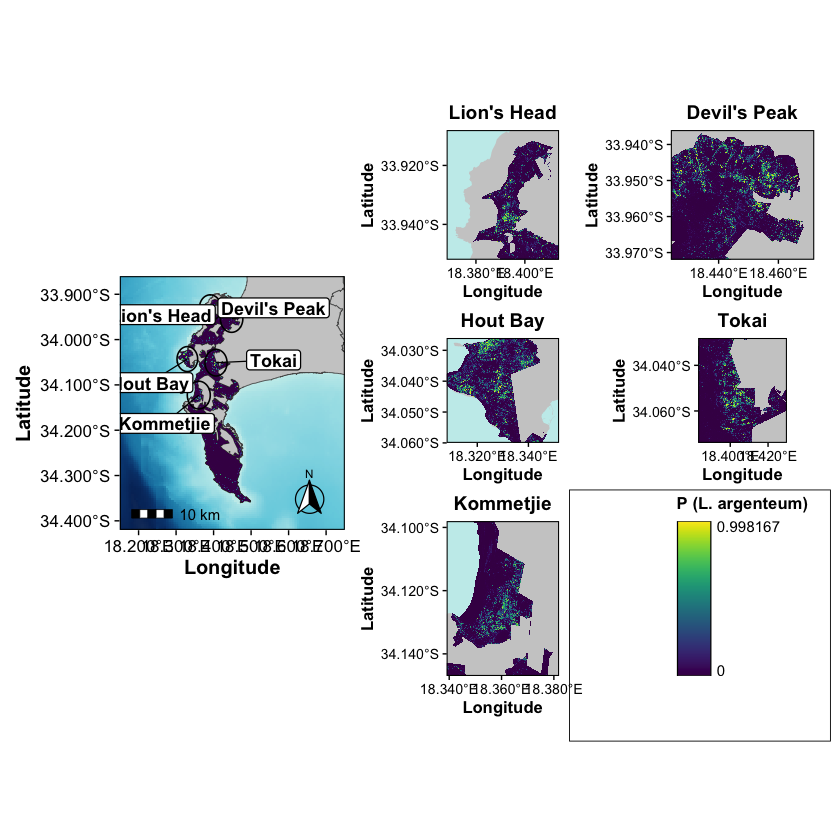

In [7]:
# =============================================================================
#  Leucadendron argenteum — XGBoost distribution probability
#  Main Cape Peninsula map + 5 zoom insets
#
#  VERSION: STANDARD VIRIDIS
#
#  Probability palette:
#  dark blue/purple -> blue -> green -> yellow
# =============================================================================


# =============================================================================
# 0. Packages
# =============================================================================

pkgs <- c(
  "terra",
  "sf",
  "marmap",
  "ggplot2",
  "tidyterra",
  "ggnewscale",
  "ggspatial",
  "ggforce",
  "patchwork",
  "scales",
  "viridisLite",
  "ragg"
)

new <- pkgs[!pkgs %in% rownames(installed.packages())]

if (length(new)) {
  install.packages(new)
}

invisible(
  lapply(
    pkgs,
    library,
    character.only = TRUE
  )
)

sf::sf_use_s2(FALSE)

terra::terraOptions(
  memfrac = 0.7
)


# =============================================================================
# 1. USER INPUTS
# =============================================================================

PROB_PATH <- "outputs/03_probability_mapping_validation/rasters/Larg_probability_TMNP_AVIRIS_LVIS_RH98_filtered.tif"

COUNTRY_PATH <- "Data/CPT/zaf_admin_boundaries/zaf_admin2.geojson"

# Optional: Table Mountain National Park boundary
# Set to NA to skip
TMNP_PATH <- "Data/Hyper/Phemelo_TMNP.shp"

OUT_PNG <- "Figure_8_structurally_filtered_probability_map.png"

OUT_PDF <- "Figure_8_structurally_filtered_probability_map.pdf"

# Main map extent
XLIM <- c(
  18.150,
  18.750
)

YLIM <- c(
  -34.420,
  -33.860
)

# Probability below this threshold becomes progressively transparent
ALPHA_FLOOR <- 0.10


# =============================================================================
# 2. COLOURS
# =============================================================================

# -----------------------------------------------------------------------------
# Bathymetry
# -----------------------------------------------------------------------------

bathy_cols <- c(
  "#5e24d6",
  "#22496d",
  "#042f66",
  "#054780",
  "#1074a6",
  "#218eb7",
  "#48b5d2",
  "#72d0e1",
  "#9ddee7",
  "#c6edec"
)


# -----------------------------------------------------------------------------
# Land
# -----------------------------------------------------------------------------

land_col <- "#CCCCCC"


# -----------------------------------------------------------------------------
# Shallow-water background
# -----------------------------------------------------------------------------

sea_shallow <- tail(
  bathy_cols,
  1
)


# -----------------------------------------------------------------------------
# STANDARD VIRIDIS
# -----------------------------------------------------------------------------
#
# dark blue / purple
#          ↓
#        blue
#          ↓
#        green
#          ↓
#      yellow-green
#          ↓
#        yellow
#
# This is the standard viridis colour sequence.
# -----------------------------------------------------------------------------

prediction_cols <- viridisLite::viridis(
  n = 256,
  option = "viridis",
  direction = 1
)


# =============================================================================
# 3. PROBABILITY RASTER
# =============================================================================

prob <- terra::rast(
  PROB_PATH
)

if (terra::nlyr(prob) > 1) {

  prob <- prob[[1]]

}

names(prob) <- "prob"


# -----------------------------------------------------------------------------
# Reproject to WGS84 if necessary
# -----------------------------------------------------------------------------

prob_crs <- terra::crs(
  prob,
  describe = TRUE
)

if (
  is.na(prob_crs$code) ||
  prob_crs$code != "4326"
) {

  prob <- terra::project(
    prob,
    "EPSG:4326",
    method = "bilinear"
  )

}


# -----------------------------------------------------------------------------
# Maximum predicted probability
# -----------------------------------------------------------------------------

PMAX <- as.numeric(
  terra::global(
    prob,
    "max",
    na.rm = TRUE
  )[1, 1]
)


# =============================================================================
# 4. BATHYMETRY
# =============================================================================

bathy <- marmap::getNOAA.bathy(
  lon1 = XLIM[1] - 0.05,
  lon2 = XLIM[2] + 0.05,
  lat1 = YLIM[1] - 0.05,
  lat2 = YLIM[2] + 0.05,
  resolution = 0.25,
  keep = TRUE
)


bathy_r <- terra::rast(
  marmap::as.raster(
    bathy
  )
)

names(bathy_r) <- "depth"

terra::crs(
  bathy_r
) <- "EPSG:4326"


# -----------------------------------------------------------------------------
# Clamp positive terrestrial elevations to zero
# -----------------------------------------------------------------------------

bathy_fill <- terra::clamp(
  bathy_r,
  upper = 0,
  values = TRUE
)


DEPTH_MIN <- as.numeric(
  terra::global(
    bathy_fill,
    "min",
    na.rm = TRUE
  )[1, 1]
)


# =============================================================================
# 5. LAND POLYGON
# =============================================================================

land <- sf::st_read(
  COUNTRY_PATH,
  quiet = TRUE
) |>
  sf::st_transform(4326) |>
  sf::st_make_valid()


land <- sf::st_crop(
  land,
  sf::st_bbox(
    c(
      xmin = XLIM[1] - 0.2,
      xmax = XLIM[2] + 0.2,
      ymin = YLIM[1] - 0.2,
      ymax = YLIM[2] + 0.2
    ),
    crs = 4326
  )
)


# =============================================================================
# 6. OPTIONAL TMNP BOUNDARY
# =============================================================================

tmnp <- if (!is.na(TMNP_PATH)) {

  sf::st_read(
    TMNP_PATH,
    quiet = TRUE
  ) |>
    sf::st_transform(4326)

} else {

  NULL

}


# =============================================================================
# 7. HELPER FUNCTIONS
# =============================================================================

lab_lon <- function(x) {

  paste0(
    formatC(
      abs(x),
      format = "f",
      digits = 3
    ),
    "\u00b0",
    ifelse(
      x < 0,
      "W",
      "E"
    )
  )

}


lab_lat <- function(y) {

  paste0(
    formatC(
      abs(y),
      format = "f",
      digits = 3
    ),
    "\u00b0",
    ifelse(
      y < 0,
      "S",
      "N"
    )
  )

}


base_theme <- function(base_size = 11) {

  theme_bw(
    base_size = base_size
  ) +

    theme(

      panel.grid = element_blank(),

      panel.border = element_rect(
        colour = "black",
        linewidth = 0.6
      ),

      axis.title = element_text(
        face = "bold",
        size = rel(1)
      ),

      axis.text = element_text(
        colour = "black",
        size = rel(0.85)
      ),

      axis.ticks = element_line(
        colour = "black",
        linewidth = 0.4
      ),

      plot.title = element_text(
        face = "bold",
        hjust = 0.5,
        size = rel(1.15)
      ),

      plot.margin = margin(
        4,
        6,
        4,
        4
      )

    )

}


# =============================================================================
# 8. PROBABILITY SCALE
# =============================================================================

prediction_scale <- function() {

  scale_fill_gradientn(
    colours = prediction_cols,
    limits = c(
      0,
      PMAX
    ),
    na.value = "transparent",
    guide = "none"
  )

}


# =============================================================================
# 9. PROBABILITY ALPHA
# =============================================================================
#
# Low probabilities fade into the underlying grey land.
#
# This is useful because standard viridis begins with a dark colour.
# Without an alpha adjustment, even low predicted probabilities can become
# visually dominant against the grey background.
# =============================================================================

prob_alpha <- function(values) {

  alpha_values <- scales::rescale(
    values,
    to = c(
      ALPHA_FLOOR,
      1
    ),
    from = c(
      0,
      PMAX
    )
  )

  alpha_values

}


# =============================================================================
# 10. INSET DEFINITIONS
# =============================================================================

insets <- data.frame(

  name = c(
    "Lion's Head",
    "Devil's Peak",
    "Hout Bay",
    "Tokai",
    "Kommetjie"
  ),

  xmin = c(
    18.368,
    18.424,
    18.308,
    18.383,
    18.339
  ),

  xmax = c(
    18.414,
    18.472,
    18.352,
    18.430,
    18.382
  ),

  ymin = c(
    -33.952,
    -33.972,
    -34.060,
    -34.074,
    -34.147
  ),

  ymax = c(
    -33.908,
    -33.936,
    -34.026,
    -34.028,
    -34.098
  ),

  lx = c(
    18.260,
    18.560,
    18.230,
    18.560,
    18.270
  ),

  ly = c(
    -33.945,
    -33.930,
    -34.095,
    -34.045,
    -34.185
  ),

  stringsAsFactors = FALSE
)


insets$cx <- (
  insets$xmin +
    insets$xmax
) / 2


insets$cy <- (
  insets$ymin +
    insets$ymax
) / 2


insets$r <- pmax(
  insets$xmax - insets$xmin,
  insets$ymax - insets$ymin
) / 1.6


# =============================================================================
# 11. MAIN PROBABILITY RASTER
# =============================================================================

prob_main <- terra::crop(
  prob,
  terra::ext(
    XLIM[1],
    XLIM[2],
    YLIM[1],
    YLIM[2]
  )
)


# =============================================================================
# 12. MAIN MAP
# =============================================================================

main <- ggplot() +

  # ---------------------------------------------------------------------------
  # Bathymetry
  # ---------------------------------------------------------------------------

  geom_spatraster(
    data = bathy_fill,
    aes(
      fill = depth
    ),
    maxcell = 2e6
  ) +

  scale_fill_gradientn(
    colours = bathy_cols,
    limits = c(
      DEPTH_MIN,
      0
    ),
    na.value = sea_shallow,
    guide = "none"
  ) +


  # New fill scale for probability raster
  ggnewscale::new_scale_fill() +


  # ---------------------------------------------------------------------------
  # Land
  # ---------------------------------------------------------------------------

  geom_sf(
    data = land,
    fill = land_col,
    colour = "grey35",
    linewidth = 0.25
  ) +


  # ---------------------------------------------------------------------------
  # Optional TMNP boundary
  # ---------------------------------------------------------------------------

  {
    if (!is.null(tmnp)) {

      geom_sf(
        data = tmnp,
        fill = NA,
        colour = "grey20",
        linewidth = 0.35
      )

    }
  } +


  # ---------------------------------------------------------------------------
  # Prediction raster
  # ---------------------------------------------------------------------------

  geom_spatraster(
    data = prob_main,
    aes(
      fill = prob
    ),
    maxcell = 4e6
  ) +

  prediction_scale() +


  # ---------------------------------------------------------------------------
  # Inset locator circles
  # ---------------------------------------------------------------------------

  ggforce::geom_circle(
    data = insets,
    aes(
      x0 = cx,
      y0 = cy,
      r = r
    ),
    inherit.aes = FALSE,
    colour = "black",
    fill = NA,
    linewidth = 0.45
  ) +


  # ---------------------------------------------------------------------------
  # Locator lines
  # ---------------------------------------------------------------------------

  geom_segment(
    data = insets,
    aes(
      x = lx,
      y = ly,
      xend = cx,
      yend = cy
    ),
    inherit.aes = FALSE,
    linewidth = 0.35,
    colour = "black"
  ) +


  # ---------------------------------------------------------------------------
  # Inset labels
  # ---------------------------------------------------------------------------

  geom_label(
    data = insets,
    aes(
      x = lx,
      y = ly,
      label = name
    ),
    inherit.aes = FALSE,
    size = 3.8,
    fontface = "bold",
    fill = "white",
    colour = "black",
    label.size = 0.35,
    label.padding = unit(
      0.16,
      "lines"
    )
  ) +


  # ---------------------------------------------------------------------------
  # Scale bar
  # ---------------------------------------------------------------------------

  ggspatial::annotation_scale(
    location = "bl",
    width_hint = 0.28,
    bar_cols = c(
      "black",
      "white"
    ),
    text_cex = 0.75,
    height = unit(
      0.18,
      "cm"
    ),
    line_width = 0.6
  ) +


  # ---------------------------------------------------------------------------
  # North arrow
  # ---------------------------------------------------------------------------

  ggspatial::annotation_north_arrow(
    location = "br",
    which_north = "true",
    height = unit(
      1.0,
      "cm"
    ),
    width = unit(
      1.0,
      "cm"
    ),
    style = north_arrow_fancy_orienteering(
      text_size = 7
    )
  ) +


  # ---------------------------------------------------------------------------
  # Coordinates
  # ---------------------------------------------------------------------------

  coord_sf(
    xlim = XLIM,
    ylim = YLIM,
    expand = FALSE,
    crs = 4326
  ) +

  scale_x_continuous(
    breaks = seq(
      18.2,
      18.7,
      0.1
    ),
    labels = lab_lon
  ) +

  scale_y_continuous(
    breaks = seq(
      -34.4,
      -33.9,
      0.1
    ),
    labels = lab_lat
  ) +

  labs(
    x = "Longitude",
    y = "Latitude"
  ) +

  base_theme(12)


# =============================================================================
# 13. INSET BUILDER
# =============================================================================

make_inset <- function(i) {

  bb <- insets[i, ]


  # Crop probability raster
  r <- terra::crop(
    prob,
    terra::ext(
      bb$xmin,
      bb$xmax,
      bb$ymin,
      bb$ymax
    )
  )


  # Crop land
  inset_land <- sf::st_crop(
    land,
    sf::st_bbox(
      c(
        xmin = bb$xmin,
        xmax = bb$xmax,
        ymin = bb$ymin,
        ymax = bb$ymax
      ),
      crs = 4326
    )
  )


  ggplot() +

    # -------------------------------------------------------------------------
    # Land
    # -------------------------------------------------------------------------

    geom_sf(
      data = inset_land,
      fill = land_col,
      colour = NA
    ) +


    # -------------------------------------------------------------------------
    # Probability raster
    # -------------------------------------------------------------------------

    geom_spatraster(
      data = r,
      aes(
        fill = prob
      ),
      maxcell = Inf
    ) +

    prediction_scale() +


    # -------------------------------------------------------------------------
    # Coordinates
    # -------------------------------------------------------------------------

    coord_sf(
      xlim = c(
        bb$xmin,
        bb$xmax
      ),
      ylim = c(
        bb$ymin,
        bb$ymax
      ),
      expand = FALSE,
      crs = 4326
    ) +

    scale_x_continuous(
      breaks = scales::breaks_pretty(3),
      labels = lab_lon
    ) +

    scale_y_continuous(
      breaks = scales::breaks_pretty(3),
      labels = lab_lat
    ) +

    labs(
      title = bb$name,
      x = "Longitude",
      y = "Latitude"
    ) +

    base_theme(10) +

    theme(
      panel.background = element_rect(
        fill = sea_shallow,
        colour = NA
      )
    )

}


# =============================================================================
# 14. CREATE INSETS
# =============================================================================

p_lion <- make_inset(1)

p_devil <- make_inset(2)

p_hout <- make_inset(3)

p_tokai <- make_inset(4)

p_komm <- make_inset(5)


# =============================================================================
# 15. PROBABILITY LEGEND
# =============================================================================

legend_panel <- local({

  n <- 256


  legend_data <- data.frame(
    y = seq(
      0,
      PMAX,
      length.out = n
    )
  )


  ggplot(
    legend_data
  ) +

    # -------------------------------------------------------------------------
    # Gradient
    # -------------------------------------------------------------------------

    geom_raster(
      aes(
        x = 1,
        y = y,
        fill = y
      )
    ) +


    # -------------------------------------------------------------------------
    # Border
    # -------------------------------------------------------------------------

    annotate(
      "rect",
      xmin = 0.5,
      xmax = 1.5,
      ymin = 0,
      ymax = PMAX,
      fill = NA,
      colour = "black",
      linewidth = 0.35
    ) +


    # -------------------------------------------------------------------------
    # Maximum probability
    # -------------------------------------------------------------------------

    annotate(
      "text",
      x = 1.68,
      y = PMAX,
      hjust = 0,
      vjust = 1,
      size = 3.2,
      label = formatC(
        PMAX,
        format = "f",
        digits = 6
      )
    ) +


    # -------------------------------------------------------------------------
    # Minimum probability
    # -------------------------------------------------------------------------

    annotate(
      "text",
      x = 1.68,
      y = 0,
      hjust = 0,
      vjust = 0,
      size = 3.2,
      label = "0"
    ) +


    # -------------------------------------------------------------------------
    # STANDARD VIRIDIS
    # -------------------------------------------------------------------------

    scale_fill_gradientn(
      colours = prediction_cols,
      guide = "none"
    ) +


    scale_x_continuous(
      limits = c(
        0.3,
        4.6
      ),
      expand = c(
        0,
        0
      )
    ) +

    scale_y_continuous(
      limits = c(
        0,
        PMAX
      ),
      expand = c(
        0,
        0
      )
    ) +

    labs(
      title = "P (L. argenteum)"
    ) +

    theme_void(
      base_size = 11
    ) +

    theme(

      plot.title = element_text(
        face = "bold",
        size = 10,
        hjust = 0.5,
        margin = margin(
          b = 2
        )
      ),

      plot.background = element_rect(
        fill = "white",
        colour = "black",
        linewidth = 0.5
      ),

      plot.margin = margin(
        4,
        10,
        10,
        10
      )

    )

})


# =============================================================================
# 16. FIGURE ASSEMBLY
# =============================================================================

design <- "
AABC
AADE
AAFG
"


fig <- patchwork::wrap_plots(
  A = main,
  B = p_lion,
  C = p_devil,
  D = p_hout,
  E = p_tokai,
  F = p_komm,
  G = legend_panel,
  design = design
)


# =============================================================================
# 17. DISPLAY FIGURE
# =============================================================================

fig


# =============================================================================
# 18. EXPORT PNG
# =============================================================================

ggsave(
  filename = OUT_PNG,
  plot = fig,
  device = ragg::agg_png,
  width = 360,
  height = 250,
  units = "mm",
  dpi = 600,
  bg = "white"
)


# =============================================================================
# 19. EXPORT PDF
# =============================================================================

ggsave(
  filename = OUT_PDF,
  plot = fig,
  device = cairo_pdf,
  width = 360,
  height = 250,
  units = "mm",
  bg = "white"
)


# =============================================================================
# 20. CONFIRM OUTPUT
# =============================================================================

message(
  "PNG written to: ",
  normalizePath(
    OUT_PNG,
    mustWork = FALSE
  )
)

message(
  "PDF written to: ",
  normalizePath(
    OUT_PDF,
    mustWork = FALSE
  )
)

## Figure 9 — Structurally filtered probability map with independent occurrences

This figure uses the same probability raster, palette, main-map extent and five
insets as Figure 8. The independent GBIF records used by the validation analysis
are read directly from:

`outputs/03_probability_mapping_validation/GBIF_occurrences_with_probabilities.gpkg`

No further occurrence filtering is performed in this publication notebook.


File already exists ; loading 'marmap_coord_18.1;-34.47;18.8;-33.81_res_0.25.csv'

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
<SpatRaster> resampled to 4002380 cells.
although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning messa

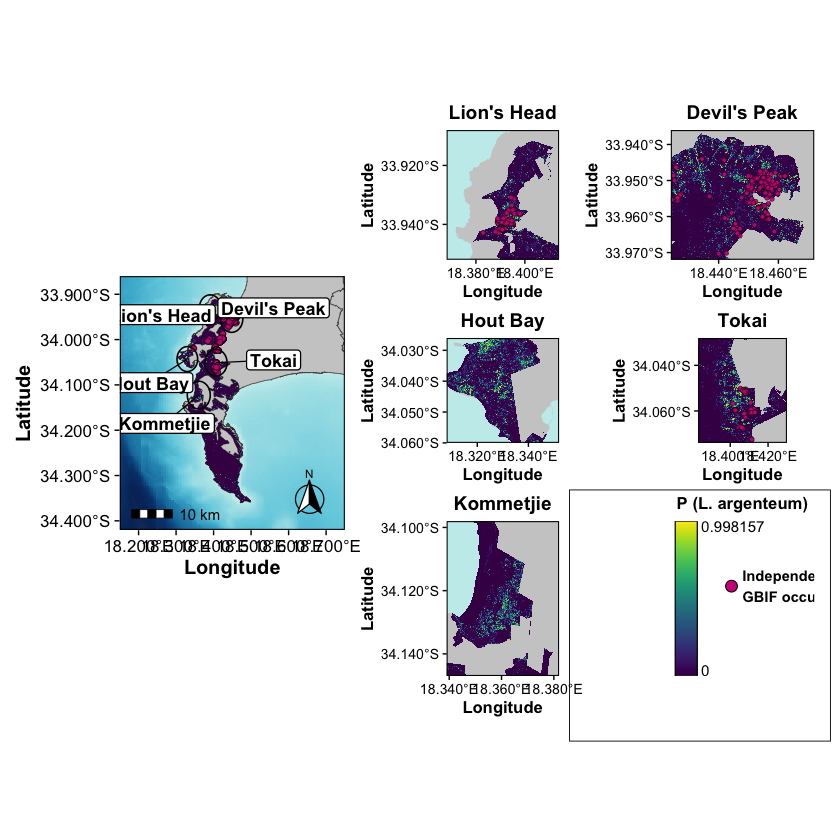

In [8]:
# =============================================================================
#  Leucadendron argenteum — XGBoost distribution probability
#  Main Cape Peninsula map + 5 zoom insets
#
#  VERSION: STANDARD VIRIDIS
#
#  Probability palette:
#  dark blue/purple -> blue -> green -> yellow
# =============================================================================


# =============================================================================
# 0. Packages
# =============================================================================

pkgs <- c(
  "terra",
  "sf",
  "marmap",
  "ggplot2",
  "tidyterra",
  "ggnewscale",
  "ggspatial",
  "ggforce",
  "patchwork",
  "scales",
  "viridisLite",
  "ragg"
)

new <- pkgs[!pkgs %in% rownames(installed.packages())]

if (length(new)) {
  install.packages(new)
}

invisible(
  lapply(
    pkgs,
    library,
    character.only = TRUE
  )
)

sf::sf_use_s2(FALSE)

terra::terraOptions(
  memfrac = 0.7
)


# =============================================================================
# 1. USER INPUTS
# =============================================================================

PROB_PATH <- "outputs/03_probability_mapping_validation/rasters/Larg_probability_TMNP_AVIRIS_LVIS_RH98_filtered.tif"

COUNTRY_PATH <- "Data/CPT/zaf_admin_boundaries/zaf_admin2.geojson"

# Optional: Table Mountain National Park boundary
# Set to NA to skip
TMNP_PATH <- "Data/Hyper/Phemelo_TMNP.shp"

# Independent occurrences exported by the revised probability-mapping notebook.
# These are the records used in the independent validation analysis.
OCCURRENCE_PATH <- paste0(
  "outputs/03_probability_mapping_validation/",
  "GBIF_occurrences_with_probabilities.gpkg"
)

OCCURRENCE_LAYER <- "independent_occurrences"

OUT_PNG <- "Figure_9_probability_map_with_independent_occurrences.png"

OUT_PDF <- "Figure_9_probability_map_with_independent_occurrences.pdf"

# Main map extent
XLIM <- c(
  18.150,
  18.750
)

YLIM <- c(
  -34.420,
  -33.860
)

# Probability below this threshold becomes progressively transparent
ALPHA_FLOOR <- 0.10


# =============================================================================
# 2. COLOURS
# =============================================================================

# -----------------------------------------------------------------------------
# Bathymetry
# -----------------------------------------------------------------------------

bathy_cols <- c(
  "#5e24d6",
  "#22496d",
  "#042f66",
  "#054780",
  "#1074a6",
  "#218eb7",
  "#48b5d2",
  "#72d0e1",
  "#9ddee7",
  "#c6edec"
)


# -----------------------------------------------------------------------------
# Land
# -----------------------------------------------------------------------------

land_col <- "#CCCCCC"


# -----------------------------------------------------------------------------
# Shallow-water background
# -----------------------------------------------------------------------------

sea_shallow <- tail(
  bathy_cols,
  1
)


# -----------------------------------------------------------------------------
# STANDARD VIRIDIS
# -----------------------------------------------------------------------------
#
# dark blue / purple
#          ↓
#        blue
#          ↓
#        green
#          ↓
#      yellow-green
#          ↓
#        yellow
#
# This is the standard viridis colour sequence.
# -----------------------------------------------------------------------------

prediction_cols <- viridisLite::viridis(
  n = 256,
  option = "viridis",
  direction = 1
)


# =============================================================================
# 3. PROBABILITY RASTER
# =============================================================================

prob <- terra::rast(
  PROB_PATH
)

if (terra::nlyr(prob) > 1) {

  prob <- prob[[1]]

}

names(prob) <- "prob"


# -----------------------------------------------------------------------------
# Reproject to WGS84 if necessary
# -----------------------------------------------------------------------------

prob_crs <- terra::crs(
  prob,
  describe = TRUE
)

if (
  is.na(prob_crs$code) ||
  prob_crs$code != "4326"
) {

  prob <- terra::project(
    prob,
    "EPSG:4326",
    method = "bilinear"
  )

}


# -----------------------------------------------------------------------------
# Maximum predicted probability
# -----------------------------------------------------------------------------

PMAX <- as.numeric(
  terra::global(
    prob,
    "max",
    na.rm = TRUE
  )[1, 1]
)


# =============================================================================
# 4. BATHYMETRY
# =============================================================================

bathy <- marmap::getNOAA.bathy(
  lon1 = XLIM[1] - 0.05,
  lon2 = XLIM[2] + 0.05,
  lat1 = YLIM[1] - 0.05,
  lat2 = YLIM[2] + 0.05,
  resolution = 0.25,
  keep = TRUE
)


bathy_r <- terra::rast(
  marmap::as.raster(
    bathy
  )
)

names(bathy_r) <- "depth"

terra::crs(
  bathy_r
) <- "EPSG:4326"


# -----------------------------------------------------------------------------
# Clamp positive terrestrial elevations to zero
# -----------------------------------------------------------------------------

bathy_fill <- terra::clamp(
  bathy_r,
  upper = 0,
  values = TRUE
)


DEPTH_MIN <- as.numeric(
  terra::global(
    bathy_fill,
    "min",
    na.rm = TRUE
  )[1, 1]
)


# =============================================================================
# 5. LAND POLYGON
# =============================================================================

land <- sf::st_read(
  COUNTRY_PATH,
  quiet = TRUE
) |>
  sf::st_transform(4326) |>
  sf::st_make_valid()


land <- sf::st_crop(
  land,
  sf::st_bbox(
    c(
      xmin = XLIM[1] - 0.2,
      xmax = XLIM[2] + 0.2,
      ymin = YLIM[1] - 0.2,
      ymax = YLIM[2] + 0.2
    ),
    crs = 4326
  )
)


# =============================================================================
# 6. OPTIONAL TMNP BOUNDARY
# =============================================================================

tmnp <- if (!is.na(TMNP_PATH)) {

  sf::st_read(
    TMNP_PATH,
    quiet = TRUE
  ) |>
    sf::st_transform(4326)

} else {

  NULL

}



# =============================================================================
# 6B. INDEPENDENT OCCURRENCES FOR FIGURE 9
# =============================================================================

occurrences <- sf::st_read(
  OCCURRENCE_PATH,
  layer = OCCURRENCE_LAYER,
  quiet = TRUE
) |>
  sf::st_transform(
    4326
  )

# The analytical notebook has already applied its coordinate-uncertainty,
# duplicate-pixel and training-neighbourhood filters. Do not filter again here.
# This notebook only renders the already-defined validation occurrence set.
occurrence_fill <- "#D01C8B"
occurrence_outline <- "black"


# =============================================================================
# 7. HELPER FUNCTIONS
# =============================================================================

lab_lon <- function(x) {

  paste0(
    formatC(
      abs(x),
      format = "f",
      digits = 3
    ),
    "\u00b0",
    ifelse(
      x < 0,
      "W",
      "E"
    )
  )

}


lab_lat <- function(y) {

  paste0(
    formatC(
      abs(y),
      format = "f",
      digits = 3
    ),
    "\u00b0",
    ifelse(
      y < 0,
      "S",
      "N"
    )
  )

}


base_theme <- function(base_size = 11) {

  theme_bw(
    base_size = base_size
  ) +

    theme(

      panel.grid = element_blank(),

      panel.border = element_rect(
        colour = "black",
        linewidth = 0.6
      ),

      axis.title = element_text(
        face = "bold",
        size = rel(1)
      ),

      axis.text = element_text(
        colour = "black",
        size = rel(0.85)
      ),

      axis.ticks = element_line(
        colour = "black",
        linewidth = 0.4
      ),

      plot.title = element_text(
        face = "bold",
        hjust = 0.5,
        size = rel(1.15)
      ),

      plot.margin = margin(
        4,
        6,
        4,
        4
      )

    )

}


# =============================================================================
# 8. PROBABILITY SCALE
# =============================================================================

prediction_scale <- function() {

  scale_fill_gradientn(
    colours = prediction_cols,
    limits = c(
      0,
      PMAX
    ),
    na.value = "transparent",
    guide = "none"
  )

}


# =============================================================================
# 9. PROBABILITY ALPHA
# =============================================================================
#
# Low probabilities fade into the underlying grey land.
#
# This is useful because standard viridis begins with a dark colour.
# Without an alpha adjustment, even low predicted probabilities can become
# visually dominant against the grey background.
# =============================================================================

prob_alpha <- function(values) {

  alpha_values <- scales::rescale(
    values,
    to = c(
      ALPHA_FLOOR,
      1
    ),
    from = c(
      0,
      PMAX
    )
  )

  alpha_values

}


# =============================================================================
# 10. INSET DEFINITIONS
# =============================================================================

insets <- data.frame(

  name = c(
    "Lion's Head",
    "Devil's Peak",
    "Hout Bay",
    "Tokai",
    "Kommetjie"
  ),

  xmin = c(
    18.368,
    18.424,
    18.308,
    18.383,
    18.339
  ),

  xmax = c(
    18.414,
    18.472,
    18.352,
    18.430,
    18.382
  ),

  ymin = c(
    -33.952,
    -33.972,
    -34.060,
    -34.074,
    -34.147
  ),

  ymax = c(
    -33.908,
    -33.936,
    -34.026,
    -34.028,
    -34.098
  ),

  lx = c(
    18.260,
    18.560,
    18.230,
    18.560,
    18.270
  ),

  ly = c(
    -33.945,
    -33.930,
    -34.095,
    -34.045,
    -34.185
  ),

  stringsAsFactors = FALSE
)


insets$cx <- (
  insets$xmin +
    insets$xmax
) / 2


insets$cy <- (
  insets$ymin +
    insets$ymax
) / 2


insets$r <- pmax(
  insets$xmax - insets$xmin,
  insets$ymax - insets$ymin
) / 1.6


# =============================================================================
# 11. MAIN PROBABILITY RASTER
# =============================================================================

prob_main <- terra::crop(
  prob,
  terra::ext(
    XLIM[1],
    XLIM[2],
    YLIM[1],
    YLIM[2]
  )
)


# =============================================================================
# 12. MAIN MAP
# =============================================================================

main <- ggplot() +

  # ---------------------------------------------------------------------------
  # Bathymetry
  # ---------------------------------------------------------------------------

  geom_spatraster(
    data = bathy_fill,
    aes(
      fill = depth
    ),
    maxcell = 2e6
  ) +

  scale_fill_gradientn(
    colours = bathy_cols,
    limits = c(
      DEPTH_MIN,
      0
    ),
    na.value = sea_shallow,
    guide = "none"
  ) +


  # New fill scale for probability raster
  ggnewscale::new_scale_fill() +


  # ---------------------------------------------------------------------------
  # Land
  # ---------------------------------------------------------------------------

  geom_sf(
    data = land,
    fill = land_col,
    colour = "grey35",
    linewidth = 0.25
  ) +


  # ---------------------------------------------------------------------------
  # Optional TMNP boundary
  # ---------------------------------------------------------------------------

  {
    if (!is.null(tmnp)) {

      geom_sf(
        data = tmnp,
        fill = NA,
        colour = "grey20",
        linewidth = 0.35
      )

    }
  } +


  # ---------------------------------------------------------------------------
  # Prediction raster
  # ---------------------------------------------------------------------------

  geom_spatraster(
    data = prob_main,
    aes(
      fill = prob
    ),
    maxcell = 4e6
  ) +

  prediction_scale() +

  # ---------------------------------------------------------------------------
  # Independent validation occurrences
  # ---------------------------------------------------------------------------

  geom_sf(
    data = occurrences,
    inherit.aes = FALSE,
    shape = 21,
    size = 1.45,
    stroke = 0.24,
    fill = occurrence_fill,
    colour = occurrence_outline,
    alpha = 0.92
  ) +


  # ---------------------------------------------------------------------------
  # Inset locator circles
  # ---------------------------------------------------------------------------

  ggforce::geom_circle(
    data = insets,
    aes(
      x0 = cx,
      y0 = cy,
      r = r
    ),
    inherit.aes = FALSE,
    colour = "black",
    fill = NA,
    linewidth = 0.45
  ) +


  # ---------------------------------------------------------------------------
  # Locator lines
  # ---------------------------------------------------------------------------

  geom_segment(
    data = insets,
    aes(
      x = lx,
      y = ly,
      xend = cx,
      yend = cy
    ),
    inherit.aes = FALSE,
    linewidth = 0.35,
    colour = "black"
  ) +


  # ---------------------------------------------------------------------------
  # Inset labels
  # ---------------------------------------------------------------------------

  geom_label(
    data = insets,
    aes(
      x = lx,
      y = ly,
      label = name
    ),
    inherit.aes = FALSE,
    size = 3.8,
    fontface = "bold",
    fill = "white",
    colour = "black",
    label.size = 0.35,
    label.padding = unit(
      0.16,
      "lines"
    )
  ) +


  # ---------------------------------------------------------------------------
  # Scale bar
  # ---------------------------------------------------------------------------

  ggspatial::annotation_scale(
    location = "bl",
    width_hint = 0.28,
    bar_cols = c(
      "black",
      "white"
    ),
    text_cex = 0.75,
    height = unit(
      0.18,
      "cm"
    ),
    line_width = 0.6
  ) +


  # ---------------------------------------------------------------------------
  # North arrow
  # ---------------------------------------------------------------------------

  ggspatial::annotation_north_arrow(
    location = "br",
    which_north = "true",
    height = unit(
      1.0,
      "cm"
    ),
    width = unit(
      1.0,
      "cm"
    ),
    style = north_arrow_fancy_orienteering(
      text_size = 7
    )
  ) +


  # ---------------------------------------------------------------------------
  # Coordinates
  # ---------------------------------------------------------------------------

  coord_sf(
    xlim = XLIM,
    ylim = YLIM,
    expand = FALSE,
    crs = 4326
  ) +

  scale_x_continuous(
    breaks = seq(
      18.2,
      18.7,
      0.1
    ),
    labels = lab_lon
  ) +

  scale_y_continuous(
    breaks = seq(
      -34.4,
      -33.9,
      0.1
    ),
    labels = lab_lat
  ) +

  labs(
    x = "Longitude",
    y = "Latitude"
  ) +

  base_theme(12)


# =============================================================================
# 13. INSET BUILDER
# =============================================================================

make_inset <- function(i) {

  bb <- insets[i, ]


  # Crop probability raster
  r <- terra::crop(
    prob,
    terra::ext(
      bb$xmin,
      bb$xmax,
      bb$ymin,
      bb$ymax
    )
  )


  # Crop land
  inset_land <- sf::st_crop(
    land,
    sf::st_bbox(
      c(
        xmin = bb$xmin,
        xmax = bb$xmax,
        ymin = bb$ymin,
        ymax = bb$ymax
      ),
      crs = 4326
    )
  )


  ggplot() +

    # -------------------------------------------------------------------------
    # Land
    # -------------------------------------------------------------------------

    geom_sf(
      data = inset_land,
      fill = land_col,
      colour = NA
    ) +


    # -------------------------------------------------------------------------
    # Probability raster
    # -------------------------------------------------------------------------

    geom_spatraster(
      data = r,
      aes(
        fill = prob
      ),
      maxcell = Inf
    ) +

    prediction_scale() +

    # -------------------------------------------------------------------------
    # Independent validation occurrences
    # -------------------------------------------------------------------------

    geom_sf(
      data = occurrences,
      inherit.aes = FALSE,
      shape = 21,
      size = 1.15,
      stroke = 0.20,
      fill = occurrence_fill,
      colour = occurrence_outline,
      alpha = 0.92
    ) +


    # -------------------------------------------------------------------------
    # Coordinates
    # -------------------------------------------------------------------------

    coord_sf(
      xlim = c(
        bb$xmin,
        bb$xmax
      ),
      ylim = c(
        bb$ymin,
        bb$ymax
      ),
      expand = FALSE,
      crs = 4326
    ) +

    scale_x_continuous(
      breaks = scales::breaks_pretty(3),
      labels = lab_lon
    ) +

    scale_y_continuous(
      breaks = scales::breaks_pretty(3),
      labels = lab_lat
    ) +

    labs(
      title = bb$name,
      x = "Longitude",
      y = "Latitude"
    ) +

    base_theme(10) +

    theme(
      panel.background = element_rect(
        fill = sea_shallow,
        colour = NA
      )
    )

}


# =============================================================================
# 14. CREATE INSETS
# =============================================================================

p_lion <- make_inset(1)

p_devil <- make_inset(2)

p_hout <- make_inset(3)

p_tokai <- make_inset(4)

p_komm <- make_inset(5)


# =============================================================================
# 15. PROBABILITY LEGEND
# =============================================================================

legend_panel <- local({

  n <- 256


  legend_data <- data.frame(
    y = seq(
      0,
      PMAX,
      length.out = n
    )
  )


  ggplot(
    legend_data
  ) +

    # -------------------------------------------------------------------------
    # Gradient
    # -------------------------------------------------------------------------

    geom_raster(
      aes(
        x = 1,
        y = y,
        fill = y
      )
    ) +


    # -------------------------------------------------------------------------
    # Border
    # -------------------------------------------------------------------------

    annotate(
      "rect",
      xmin = 0.5,
      xmax = 1.5,
      ymin = 0,
      ymax = PMAX,
      fill = NA,
      colour = "black",
      linewidth = 0.35
    ) +


    # -------------------------------------------------------------------------
    # Maximum probability
    # -------------------------------------------------------------------------

    annotate(
      "text",
      x = 1.68,
      y = PMAX,
      hjust = 0,
      vjust = 1,
      size = 3.2,
      label = formatC(
        PMAX,
        format = "f",
        digits = 6
      )
    ) +


    # -------------------------------------------------------------------------
    # Minimum probability
    # -------------------------------------------------------------------------

    annotate(
      "text",
      x = 1.68,
      y = 0,
      hjust = 0,
      vjust = 0,
      size = 3.2,
      label = "0"
    ) +


    annotate(
      "point",
      x = 3.05,
      y = PMAX * 0.58,
      shape = 21,
      size = 3.0,
      stroke = 0.45,
      fill = occurrence_fill,
      colour = occurrence_outline
    ) +

    annotate(
      "text",
      x = 3.55,
      y = PMAX * 0.58,
      hjust = 0,
      vjust = 0.5,
      size = 3.1,
      fontface = "bold",
      label = "Independent\nGBIF occurrence"
    ) +


    # -------------------------------------------------------------------------
    # STANDARD VIRIDIS
    # -------------------------------------------------------------------------

    scale_fill_gradientn(
      colours = prediction_cols,
      guide = "none"
    ) +


    scale_x_continuous(
      limits = c(
        0.3,
        6.8
      ),
      expand = c(
        0,
        0
      )
    ) +

    scale_y_continuous(
      limits = c(
        0,
        PMAX
      ),
      expand = c(
        0,
        0
      )
    ) +

    labs(
      title = "P (L. argenteum)"
    ) +

    theme_void(
      base_size = 11
    ) +

    theme(

      plot.title = element_text(
        face = "bold",
        size = 10,
        hjust = 0.5,
        margin = margin(
          b = 2
        )
      ),

      plot.background = element_rect(
        fill = "white",
        colour = "black",
        linewidth = 0.5
      ),

      plot.margin = margin(
        4,
        10,
        10,
        10
      )

    )

})


# =============================================================================
# 16. FIGURE ASSEMBLY
# =============================================================================

design <- "
AABC
AADE
AAFG
"


fig <- patchwork::wrap_plots(
  A = main,
  B = p_lion,
  C = p_devil,
  D = p_hout,
  E = p_tokai,
  F = p_komm,
  G = legend_panel,
  design = design
)


# =============================================================================
# 17. DISPLAY FIGURE
# =============================================================================

fig


# =============================================================================
# 18. EXPORT PNG
# =============================================================================

ggsave(
  filename = OUT_PNG,
  plot = fig,
  device = ragg::agg_png,
  width = 360,
  height = 250,
  units = "mm",
  dpi = 600,
  bg = "white"
)


# =============================================================================
# 19. EXPORT PDF
# =============================================================================

ggsave(
  filename = OUT_PDF,
  plot = fig,
  device = cairo_pdf,
  width = 360,
  height = 250,
  units = "mm",
  bg = "white"
)


# =============================================================================
# 20. CONFIRM OUTPUT
# =============================================================================

message(
  "PNG written to: ",
  normalizePath(
    OUT_PNG,
    mustWork = FALSE
  )
)

message(
  "PDF written to: ",
  normalizePath(
    OUT_PDF,
    mustWork = FALSE
  )
)

File already exists ; loading 'marmap_coord_18.1;-34.47;18.8;-33.81_res_0.25.csv'

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
Independent occurrences plotted: 644

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

although coordinates are longitude/latitude, st_intersection assumes that they
are planar



          name     xmin     xmax      ymin      ymax
1  Lion's Head 18.36800 18.41400 -33.95200 -33.90800
2 Devil's Peak 18.42400 18.47200 -33.97200 -33.93600
3   Judas Peak 18.33983 18.39398 -34.02700 -33.99604
4        Tokai 18.38300 18.43000 -34.07400 -34.02800
5      Cecilia 18.39616 18.43345 -34.03181 -33.97994


<SpatRaster> resampled to 4002380 cells.
although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geomet

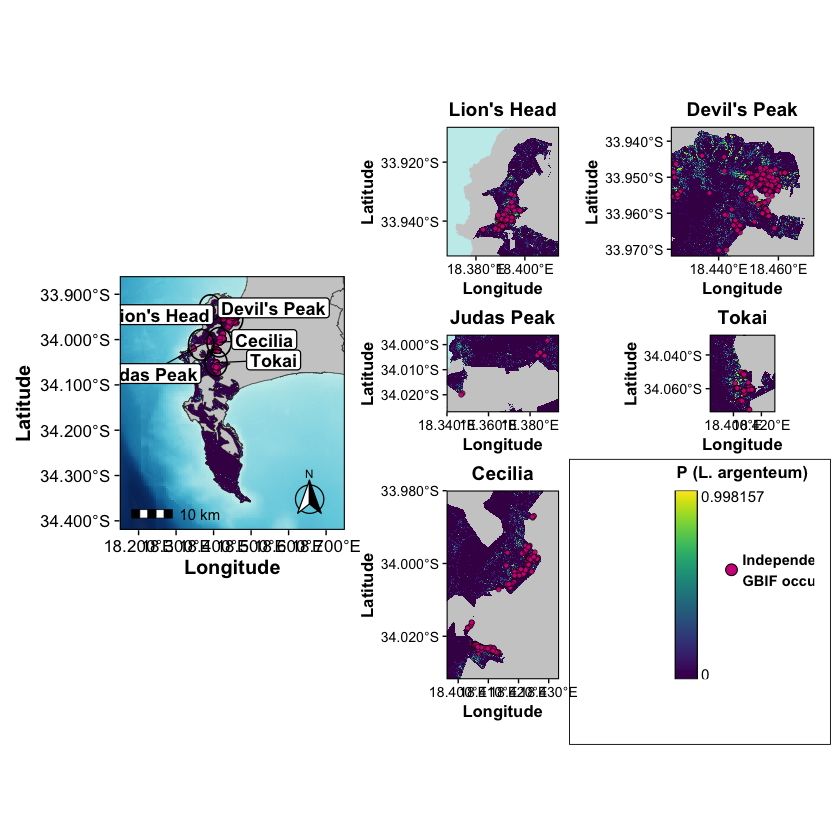

In [10]:
# =============================================================================
# Figure 9 — Structurally filtered probability map
# with independent GBIF occurrences
# =============================================================================

## Packages -------------------------------------------------------------------
pkgs <- c(
  "terra", "sf", "marmap", "ggplot2", "tidyterra",
  "ggnewscale", "ggspatial", "ggforce", "patchwork",
  "scales", "viridisLite", "ragg"
)

new <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(new)) install.packages(new)
invisible(lapply(pkgs, library, character.only = TRUE))

sf::sf_use_s2(FALSE)
terra::terraOptions(memfrac = 0.7)

## Inputs ---------------------------------------------------------------------
PROB_PATH <- paste0(
  "outputs/03_probability_mapping_validation/rasters/",
  "Larg_probability_TMNP_AVIRIS_LVIS_RH98_filtered.tif"
)

COUNTRY_PATH <- "Data/CPT/zaf_admin_boundaries/zaf_admin2.geojson"
TMNP_PATH <- "Data/Hyper/Phemelo_TMNP.shp"

OCCURRENCE_PATH <- paste0(
  "outputs/03_probability_mapping_validation/",
  "GBIF_occurrences_with_probabilities.gpkg"
)

OCCURRENCE_LAYER <- "independent_occurrences"

OUT_PNG <- "Figure_9_probability_map_with_independent_occurrences.png"
OUT_PDF <- "Figure_9_probability_map_with_independent_occurrences.pdf"

XLIM <- c(18.150, 18.750)
YLIM <- c(-34.420, -33.860)

## Colours --------------------------------------------------------------------
bathy_cols <- c(
  "#5e24d6", "#22496d", "#042f66", "#054780", "#1074a6",
  "#218eb7", "#48b5d2", "#72d0e1", "#9ddee7", "#c6edec"
)

land_col <- "#CCCCCC"
sea_shallow <- tail(bathy_cols, 1)

prediction_cols <- viridisLite::viridis(
  256,
  option = "viridis",
  direction = 1
)

occurrence_fill <- "#D01C8B"
occurrence_outline <- "black"

## Probability raster ---------------------------------------------------------
prob <- terra::rast(PROB_PATH)

if (terra::nlyr(prob) > 1) {
  prob <- prob[[1]]
}

names(prob) <- "prob"

prob_crs <- terra::crs(prob, describe = TRUE)

if (is.na(prob_crs$code) || prob_crs$code != "4326") {
  prob <- terra::project(
    prob,
    "EPSG:4326",
    method = "bilinear"
  )
}

PMAX <- as.numeric(
  terra::global(
    prob,
    "max",
    na.rm = TRUE
  )[1, 1]
)

## Bathymetry -----------------------------------------------------------------
bathy <- marmap::getNOAA.bathy(
  lon1 = XLIM[1] - 0.05,
  lon2 = XLIM[2] + 0.05,
  lat1 = YLIM[1] - 0.05,
  lat2 = YLIM[2] + 0.05,
  resolution = 0.25,
  keep = TRUE
)

bathy_r <- terra::rast(
  marmap::as.raster(bathy)
)

names(bathy_r) <- "depth"
terra::crs(bathy_r) <- "EPSG:4326"

bathy_fill <- terra::clamp(
  bathy_r,
  upper = 0,
  values = TRUE
)

DEPTH_MIN <- as.numeric(
  terra::global(
    bathy_fill,
    "min",
    na.rm = TRUE
  )[1, 1]
)

## Land and park boundary -----------------------------------------------------
land <- sf::st_read(
  COUNTRY_PATH,
  quiet = TRUE
) |>
  sf::st_transform(4326) |>
  sf::st_make_valid()

land <- sf::st_crop(
  land,
  sf::st_bbox(
    c(
      xmin = XLIM[1] - 0.2,
      xmax = XLIM[2] + 0.2,
      ymin = YLIM[1] - 0.2,
      ymax = YLIM[2] + 0.2
    ),
    crs = 4326
  )
)

tmnp <- sf::st_read(
  TMNP_PATH,
  quiet = TRUE
) |>
  sf::st_transform(4326)

## Independent occurrence records --------------------------------------------
occurrences <- sf::st_read(
  OCCURRENCE_PATH,
  layer = OCCURRENCE_LAYER,
  quiet = TRUE
) |>
  sf::st_transform(4326)

message(
  "Independent occurrences plotted: ",
  nrow(occurrences)
)

## Axis labels ----------------------------------------------------------------
lab_lon <- function(x) {
  paste0(
    formatC(abs(x), format = "f", digits = 3),
    "\u00b0",
    ifelse(x < 0, "W", "E")
  )
}

lab_lat <- function(y) {
  paste0(
    formatC(abs(y), format = "f", digits = 3),
    "\u00b0",
    ifelse(y < 0, "S", "N")
  )
}

base_theme <- function(base_size = 11) {
  theme_bw(base_size = base_size) +
    theme(
      panel.grid = element_blank(),
      panel.border = element_rect(
        colour = "black",
        linewidth = 0.6
      ),
      axis.title = element_text(
        face = "bold",
        size = rel(1)
      ),
      axis.text = element_text(
        colour = "black",
        size = rel(0.85)
      ),
      axis.ticks = element_line(
        colour = "black",
        linewidth = 0.4
      ),
      plot.title = element_text(
        face = "bold",
        hjust = 0.5,
        size = rel(1.15)
      ),
      plot.margin = margin(4, 6, 4, 4)
    )
}

prediction_scale <- function() {
  scale_fill_gradientn(
    colours = prediction_cols,
    limits = c(0, PMAX),
    na.value = "transparent",
    guide = "none"
  )
}

## Occurrence-driven inset helper ---------------------------------------------
#
# For Cecilia and Judas Peak, broad search windows are supplied below.
# The final inset limits are then calculated from the occurrence points
# actually found inside those windows, with a small padding around them.
#
occurrence_inset <- function(name, xmin, xmax, ymin, ymax, pad = 0.006) {

  search_box <- sf::st_bbox(
    c(
      xmin = xmin,
      xmax = xmax,
      ymin = ymin,
      ymax = ymax
    ),
    crs = 4326
  )

  selected <- suppressWarnings(
    sf::st_crop(
      occurrences,
      search_box
    )
  )

  if (!nrow(selected)) {
    stop(
      "No independent occurrence points found in the search window for ",
      name
    )
  }

  occurrence_box <- sf::st_bbox(selected)

  data.frame(
    name = name,
    xmin = as.numeric(occurrence_box["xmin"]) - pad,
    xmax = as.numeric(occurrence_box["xmax"]) + pad,
    ymin = as.numeric(occurrence_box["ymin"]) - pad,
    ymax = as.numeric(occurrence_box["ymax"]) + pad
  )
}

## Inset definitions -----------------------------------------------------------
#
# Lion's Head, Devil's Peak and Tokai retain the original map extents.
#
# Judas Peak replaces Hout Bay.
# Cecilia replaces Kommetjie.
#
# The broad Judas Peak and Cecilia windows are used only to select the relevant
# occurrence clusters; the actual inset dimensions are calculated from those
# occurrence coordinates.
#
judas_peak <- occurrence_inset(
  name = "Judas Peak",
  xmin = 18.340,
  xmax = 18.395,
  ymin = -34.045,
  ymax = -34.000,
  pad = 0.007
)

cecilia <- occurrence_inset(
  name = "Cecilia",
  xmin = 18.390,
  xmax = 18.435,
  ymin = -34.030,
  ymax = -33.980,
  pad = 0.007
)

insets <- rbind(
  data.frame(
    name = "Lion's Head",
    xmin = 18.368,
    xmax = 18.414,
    ymin = -33.952,
    ymax = -33.908
  ),
  data.frame(
    name = "Devil's Peak",
    xmin = 18.424,
    xmax = 18.472,
    ymin = -33.972,
    ymax = -33.936
  ),
  judas_peak,
  data.frame(
    name = "Tokai",
    xmin = 18.383,
    xmax = 18.430,
    ymin = -34.074,
    ymax = -34.028
  ),
  cecilia
)

## Label locations on the main map --------------------------------------------
#
# These control only the locator labels and connecting lines.
#
insets$lx <- c(
  18.255,  # Lion's Head
  18.560,  # Devil's Peak
  18.225,  # Judas Peak
  18.560,  # Tokai
  18.535   # Cecilia
)

insets$ly <- c(
  -33.945,
  -33.930,
  -34.075,
  -34.045,
  -34.000
)

insets$cx <- (insets$xmin + insets$xmax) / 2
insets$cy <- (insets$ymin + insets$ymax) / 2

insets$r <- pmax(
  insets$xmax - insets$xmin,
  insets$ymax - insets$ymin
) / 1.6

print(
  insets[
    ,
    c(
      "name",
      "xmin",
      "xmax",
      "ymin",
      "ymax"
    )
  ]
)

## Main probability raster ----------------------------------------------------
prob_main <- terra::crop(
  prob,
  terra::ext(
    XLIM[1],
    XLIM[2],
    YLIM[1],
    YLIM[2]
  )
)

## Main map -------------------------------------------------------------------
main <- ggplot() +

  geom_spatraster(
    data = bathy_fill,
    aes(fill = depth),
    maxcell = 2e6
  ) +

  scale_fill_gradientn(
    colours = bathy_cols,
    limits = c(DEPTH_MIN, 0),
    na.value = sea_shallow,
    guide = "none"
  ) +

  ggnewscale::new_scale_fill() +

  geom_sf(
    data = land,
    fill = land_col,
    colour = "grey35",
    linewidth = 0.25
  ) +

  geom_sf(
    data = tmnp,
    fill = NA,
    colour = "grey20",
    linewidth = 0.35
  ) +

  geom_spatraster(
    data = prob_main,
    aes(fill = prob),
    maxcell = 4e6
  ) +

  prediction_scale() +

  geom_sf(
    data = occurrences,
    inherit.aes = FALSE,
    shape = 21,
    size = 1.45,
    stroke = 0.24,
    fill = occurrence_fill,
    colour = occurrence_outline,
    alpha = 0.92
  ) +

  ggforce::geom_circle(
    data = insets,
    aes(
      x0 = cx,
      y0 = cy,
      r = r
    ),
    inherit.aes = FALSE,
    colour = "black",
    fill = NA,
    linewidth = 0.45
  ) +

  geom_segment(
    data = insets,
    aes(
      x = lx,
      y = ly,
      xend = cx,
      yend = cy
    ),
    inherit.aes = FALSE,
    linewidth = 0.35,
    colour = "black"
  ) +

  geom_label(
    data = insets,
    aes(
      x = lx,
      y = ly,
      label = name
    ),
    inherit.aes = FALSE,
    size = 3.8,
    fontface = "bold",
    fill = "white",
    colour = "black",
    label.size = 0.35,
    label.padding = unit(0.16, "lines")
  ) +

  ggspatial::annotation_scale(
    location = "bl",
    width_hint = 0.28,
    bar_cols = c("black", "white"),
    text_cex = 0.75,
    height = unit(0.18, "cm"),
    line_width = 0.6
  ) +

  ggspatial::annotation_north_arrow(
    location = "br",
    which_north = "true",
    height = unit(1, "cm"),
    width = unit(1, "cm"),
    style = north_arrow_fancy_orienteering(
      text_size = 7
    )
  ) +

  coord_sf(
    xlim = XLIM,
    ylim = YLIM,
    expand = FALSE,
    crs = 4326
  ) +

  scale_x_continuous(
    breaks = seq(18.2, 18.7, 0.1),
    labels = lab_lon
  ) +

  scale_y_continuous(
    breaks = seq(-34.4, -33.9, 0.1),
    labels = lab_lat
  ) +

  labs(
    x = "Longitude",
    y = "Latitude"
  ) +

  base_theme(12)

## Inset builder ---------------------------------------------------------------
make_inset <- function(i) {

  bb <- insets[i, ]

  inset_prob <- terra::crop(
    prob,
    terra::ext(
      bb$xmin,
      bb$xmax,
      bb$ymin,
      bb$ymax
    )
  )

  inset_land <- sf::st_crop(
    land,
    sf::st_bbox(
      c(
        xmin = bb$xmin,
        xmax = bb$xmax,
        ymin = bb$ymin,
        ymax = bb$ymax
      ),
      crs = 4326
    )
  )

  ggplot() +

    geom_sf(
      data = inset_land,
      fill = land_col,
      colour = NA
    ) +

    geom_spatraster(
      data = inset_prob,
      aes(fill = prob),
      maxcell = Inf
    ) +

    prediction_scale() +

    geom_sf(
      data = occurrences,
      inherit.aes = FALSE,
      shape = 21,
      size = 1.25,
      stroke = 0.22,
      fill = occurrence_fill,
      colour = occurrence_outline,
      alpha = 0.95
    ) +

    coord_sf(
      xlim = c(bb$xmin, bb$xmax),
      ylim = c(bb$ymin, bb$ymax),
      expand = FALSE,
      crs = 4326
    ) +

    scale_x_continuous(
      breaks = scales::breaks_pretty(3),
      labels = lab_lon
    ) +

    scale_y_continuous(
      breaks = scales::breaks_pretty(3),
      labels = lab_lat
    ) +

    labs(
      title = bb$name,
      x = "Longitude",
      y = "Latitude"
    ) +

    base_theme(10) +

    theme(
      panel.background = element_rect(
        fill = sea_shallow,
        colour = NA
      )
    )
}

## Create insets ---------------------------------------------------------------
p_lion <- make_inset(1)
p_devil <- make_inset(2)
p_judas <- make_inset(3)
p_tokai <- make_inset(4)
p_cecilia <- make_inset(5)

## Probability legend ----------------------------------------------------------
legend_panel <- local({

  legend_data <- data.frame(
    y = seq(
      0,
      PMAX,
      length.out = 256
    )
  )

  ggplot(
    legend_data
  ) +

    geom_raster(
      aes(
        x = 1,
        y = y,
        fill = y
      )
    ) +

    annotate(
      "rect",
      xmin = 0.5,
      xmax = 1.5,
      ymin = 0,
      ymax = PMAX,
      fill = NA,
      colour = "black",
      linewidth = 0.35
    ) +

    annotate(
      "text",
      x = 1.68,
      y = PMAX,
      label = formatC(
        PMAX,
        format = "f",
        digits = 6
      ),
      hjust = 0,
      vjust = 1,
      size = 3.2
    ) +

    annotate(
      "text",
      x = 1.68,
      y = 0,
      label = "0",
      hjust = 0,
      vjust = 0,
      size = 3.2
    ) +

    annotate(
      "point",
      x = 3.05,
      y = PMAX * 0.58,
      shape = 21,
      size = 3,
      stroke = 0.45,
      fill = occurrence_fill,
      colour = occurrence_outline
    ) +

    annotate(
      "text",
      x = 3.55,
      y = PMAX * 0.58,
      label = "Independent\nGBIF occurrence",
      hjust = 0,
      vjust = 0.5,
      size = 3.1,
      fontface = "bold"
    ) +

    scale_fill_gradientn(
      colours = prediction_cols,
      guide = "none"
    ) +

    scale_x_continuous(
      limits = c(0.3, 6.8),
      expand = c(0, 0)
    ) +

    scale_y_continuous(
      limits = c(0, PMAX),
      expand = c(0, 0)
    ) +

    labs(
      title = "P (L. argenteum)"
    ) +

    theme_void(
      base_size = 11
    ) +

    theme(
      plot.title = element_text(
        face = "bold",
        size = 10,
        hjust = 0.5,
        margin = margin(b = 2)
      ),
      plot.background = element_rect(
        fill = "white",
        colour = "black",
        linewidth = 0.5
      ),
      plot.margin = margin(4, 10, 10, 10)
    )
})

## Assemble -------------------------------------------------------------------
design <- "
AABC
AADE
AAFG
"

fig <- patchwork::wrap_plots(
  A = main,
  B = p_lion,
  C = p_devil,
  D = p_judas,
  E = p_tokai,
  F = p_cecilia,
  G = legend_panel,
  design = design
)

fig

## Export ---------------------------------------------------------------------
ggsave(
  OUT_PNG,
  fig,
  device = ragg::agg_png,
  width = 360,
  height = 250,
  units = "mm",
  dpi = 600,
  bg = "white"
)

ggsave(
  OUT_PDF,
  fig,
  device = cairo_pdf,
  width = 360,
  height = 250,
  units = "mm",
  bg = "white"
)

message("PNG written to: ", normalizePath(OUT_PNG, mustWork = FALSE))
message("PDF written to: ", normalizePath(OUT_PDF, mustWork = FALSE))

## Field-sampled species map — all spectral-library observations

This map shows whether and where each of the 26 taxa represented in the field
spectral library was sampled across the Cape Peninsula. The original crossed
colour × symbol encoding is retained, together with the Table Mountain and
Silvermine–Tokai zoom panels.


In [9]:
# =============================================================================
#  Field-sampled fynbos species across the Cape Peninsula
#  Bathymetry + land + TMNP + 26 species as outline symbols
#  Main map + Table Mountain and Silvermine/Tokai insets + combined legend
#
#  ENCODING
#  --------
#  26 categories cannot be separated by colour alone — not by anyone, and
#  certainly not under colour-vision deficiency, where the usable number of
#  reliably distinct hues drops to about seven. So the species key is CROSSED:
#
#       colour  = taxonomic block (7 Okabe-Ito colours)
#       shape   = species within that block (4 open symbols: o square triangle diamond)
#
#  7 x 4 = 28 slots for 26 species. Every species is uniquely identified by the
#  PAIR, and either channel alone still carries real information: colour tells
#  you the taxonomic block, shape separates members within it. Someone who
#  cannot resolve vermillion from orange still reads four distinct symbols, and
#  the whole key survives greyscale printing.
#
#  Measured separation of the seven colours (CIEDE2000 on Vienot-simulated
#  renderings), including against both background fills:
#       normal        min dE00 = 20.8
#       deuteranopia  min dE00 = 12.7
#       protanopia    min dE00 = 12.2
#       tritanopia    min dE00 =  0.6  (vermillion/reddish-purple collapse —
#                                       this is the case the shapes carry)
# =============================================================================


## ---- 0. Packages ------------------------------------------------------------
pkgs <- c("terra", "sf", "marmap", "ggplot2", "tidyterra", "ggnewscale",
          "ggspatial", "ggforce", "patchwork", "scales", "ragg")
new  <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(new)) install.packages(new)
invisible(lapply(pkgs, library, character.only = TRUE))

sf::sf_use_s2(FALSE)
terra::terraOptions(memfrac = 0.7)


## ---- 1. USER INPUTS ---------------------------------------------------------
SPECIES_CSV   <- "Data/Hyperspectral/Outputs/Species_data_final4.csv"
DISTRICT_PATH <- "Data/CPT/zaf_admin_boundaries/zaf_admin2.geojson"
TMNP_PATH     <- "Data/Hyper/Phemelo_TMNP.shp"

OUT_PNG <- "Figure_Samples_all_species_TMNP.png"
OUT_PDF <- "Figure_Samples_all_species_TMNP.pdf"

# Main map extent (lon/lat, WGS84)
XLIM <- c(18.280, 18.660)
YLIM <- c(-34.365, -33.840)

# Zoom windows — edit freely
ZOOMS <- data.frame(
  name = c("Table Mountain & Devil's Peak", "Silvermine & Tokai"),
  xmin = c(18.380, 18.380),
  xmax = c(18.450, 18.470),
  ymin = c(-34.010, -34.110),
  ymax = c(-33.930, -34.020),
  stringsAsFactors = FALSE
)

PT_SIZE   <- 1.45          # symbol size on the main map
PT_STROKE <- 0.45          # outline weight
PT_ALPHA  <- 0.9


## ---- 2. Colours -------------------------------------------------------------
bathy_cols <- c("#5e24d6", "#22496d", "#042f66", "#054780", "#1074a6",
                "#218eb7", "#48b5d2", "#72d0e1", "#9ddee7", "#c6edec")
land_col    <- "#CCCCCC"
tmnp_fill   <- "#B4D79E"
tmnp_line   <- "#5F8B4C"
sea_shallow <- tail(bathy_cols, 1)

# Okabe & Ito (2008) — the seven block colours
BLOCK_COLS <- c(
  "Proteaceae: Protea & Leucospermum"      = "#0072B2",  # blue
  "Proteaceae: Leucadendron & Mimetes"     = "#009E73",  # bluish green
  "Proteaceae: Serruria; Ericaceae"        = "#D55E00",  # vermillion
  "Droseraceae; Orchidaceae; Campanulaceae" = "#CC79A7", # reddish purple
  "Iridaceae; Dennstaedtiaceae"            = "#E69F00",  # orange
  "Fabaceae; Geraniaceae; Apiaceae"        = "#56B4E9",  # sky blue
  "Asteraceae; Bruniaceae"                 = "#000000"   # black
)

# Open (unfilled) symbols only — pch 1/0/2/5 use `colour` for the outline and
# have no interior, so overlapping records stay readable.
BLOCK_SHAPES <- c(1, 0, 2, 5)   # circle, square, triangle, diamond


## ---- 3. Species key ---------------------------------------------------------
# One row per species: which colour block it belongs to, and which of the four
# symbols identifies it inside that block. Legend order follows this table.
species_key <- rbind(
  data.frame(block = names(BLOCK_COLS)[1], species = c(
    "Protea cynaroides", "Protea lepidocarpodendron", "Protea speciosa",
    "Leucospermum conocarpodendron viridum")),
  data.frame(block = names(BLOCK_COLS)[2], species = c(
    "Leucadendron argenteum", "Leucadendron xanthoconus",
    "Mimetes fimbriifolius", "Mimetes hirtus")),
  data.frame(block = names(BLOCK_COLS)[3], species = c(
    "Serruria glomerata", "Serruria villosa",
    "Erica corifolia", "Erica pyxidiflora")),
  data.frame(block = names(BLOCK_COLS)[4], species = c(
    "Drosera aliciae", "Drosera cuneifolia",
    "Disa rosea", "Roella ciliata")),
  data.frame(block = names(BLOCK_COLS)[5], species = c(
    "Gladiolus carneus", "Watsonia tabularis", "Witsenia maura",
    "Pteridium aquilinum capense")),
  data.frame(block = names(BLOCK_COLS)[6], species = c(
    "Liparia splendens splendens", "Psoralea fruticans",
    "Pelargonium cucullatum tabulare", "Hermas villosa")),
  data.frame(block = names(BLOCK_COLS)[7], species = c(
    "Syncarpha vestita", "Audouinia capitata")),
  stringsAsFactors = FALSE
)

species_key$colour <- unname(BLOCK_COLS[species_key$block])
species_key$shape  <- ave(seq_len(nrow(species_key)), species_key$block,
                          FUN = function(i) BLOCK_SHAPES[seq_along(i)])

SPP_LEVELS <- species_key$species
SPP_COLS   <- setNames(species_key$colour, species_key$species)
SPP_SHAPES <- setNames(species_key$shape,  species_key$species)

TARGET <- "Leucadendron argenteum"   # drawn last, at heavier weight


## ---- 4. Data ----------------------------------------------------------------
occ_raw <- read.csv(SPECIES_CSV, stringsAsFactors = FALSE)

# Guard against silent mismatches between the CSV and the key above
missing_in_key <- setdiff(unique(occ_raw$Scientific.Names), SPP_LEVELS)
missing_in_csv <- setdiff(SPP_LEVELS, unique(occ_raw$Scientific.Names))
if (length(missing_in_key))
  warning("Not in species_key: ", paste(missing_in_key, collapse = "; "))
if (length(missing_in_csv))
  warning("Not in CSV: ", paste(missing_in_csv, collapse = "; "))

occ <- sf::st_as_sf(
  occ_raw,
  coords = c("Longitude", "Latitude"),
  crs    = 4326,
  remove = FALSE
)
occ$species <- factor(occ$Scientific.Names, levels = SPP_LEVELS)
occ <- occ[!is.na(occ$species), ]

pad_bbox <- function(xlim, ylim, pad = 0.25)
  sf::st_bbox(c(xmin = xlim[1] - pad, xmax = xlim[2] + pad,
                ymin = ylim[1] - pad, ymax = ylim[2] + pad), crs = 4326)

districts <- sf::st_read(DISTRICT_PATH, quiet = TRUE) |>
  sf::st_transform(4326) |> sf::st_make_valid() |>
  sf::st_crop(pad_bbox(XLIM, YLIM))

tmnp <- sf::st_read(TMNP_PATH, quiet = TRUE) |>
  sf::st_transform(4326) |> sf::st_make_valid()


## ---- 5. Bathymetry ----------------------------------------------------------
bathy <- marmap::getNOAA.bathy(
  lon1 = XLIM[1] - 0.05, lon2 = XLIM[2] + 0.05,
  lat1 = YLIM[1] - 0.05, lat2 = YLIM[2] + 0.05,
  resolution = 0.25, keep = TRUE
)

bathy_r <- terra::rast(marmap::as.raster(bathy))
names(bathy_r) <- "depth"
terra::crs(bathy_r) <- "EPSG:4326"

bathy_fill <- terra::clamp(bathy_r, upper = 0, values = TRUE)
DEPTH_MIN  <- as.numeric(terra::global(bathy_fill, "min", na.rm = TRUE)[1, 1])


## ---- 6. Helpers -------------------------------------------------------------
lab_lon <- function(x)
  paste0(formatC(abs(x), format = "f", digits = 2), "\u00b0",
         ifelse(x < 0, "W", "E"))

lab_lat <- function(y)
  paste0(formatC(abs(y), format = "f", digits = 2), "\u00b0",
         ifelse(y < 0, "S", "N"))

base_theme <- function(base_size = 11) {
  theme_bw(base_size = base_size) +
    theme(
      panel.grid      = element_blank(),
      panel.border    = element_rect(colour = "black", linewidth = 0.6),
      panel.background = element_rect(fill = sea_shallow, colour = NA),
      axis.title      = element_text(face = "bold", size = rel(1.0)),
      axis.text       = element_text(colour = "black", size = rel(0.8)),
      axis.ticks      = element_line(colour = "black", linewidth = 0.4),
      plot.title      = element_text(face = "bold", hjust = 0.5, size = rel(1.05)),
      plot.margin     = margin(4, 6, 4, 4)
    )
}

# Both scales map the same variable, so ggplot merges them into ONE legend
# with the colour and the shape shown together on each key.
species_scales <- function(show_guide = FALSE) {
  gd <- if (show_guide)
    guide_legend(
      ncol = 2, byrow = FALSE,
      override.aes = list(size = 2.4, stroke = 0.7),
      keyheight = unit(0.95, "lines")
    ) else "none"

  list(
    scale_colour_manual(values = SPP_COLS,   limits = SPP_LEVELS,
                        drop = FALSE, name = NULL, guide = gd),
    scale_shape_manual( values = SPP_SHAPES, limits = SPP_LEVELS,
                        drop = FALSE, name = NULL, guide = gd)
  )
}


## ---- 7. Map builder ---------------------------------------------------------
build_map <- function(xlim, ylim, title = NULL, pt_size = PT_SIZE,
                      bx = 3, show_guide = FALSE, base_size = 11) {

  win  <- pad_bbox(xlim, ylim, pad = 0)
  occ_w <- suppressWarnings(sf::st_crop(occ, win))

  ggplot() +

    # bathymetry
    geom_spatraster(data = bathy_fill, aes(fill = depth), maxcell = 2e6) +
    scale_fill_gradientn(colours = bathy_cols, limits = c(DEPTH_MIN, 0),
                         na.value = sea_shallow, guide = "none") +
    ggnewscale::new_scale_fill() +

    # land + park
    geom_sf(data = districts, fill = land_col, colour = "grey25",
            linewidth = 0.3) +
    geom_sf(data = tmnp, fill = tmnp_fill, colour = tmnp_line,
            linewidth = 0.3) +

    # occurrences — everything except the study species
    geom_sf(data = subset(occ_w, species != TARGET),
            aes(colour = species, shape = species),
            size = pt_size, stroke = PT_STROKE, alpha = PT_ALPHA,
            show.legend = TRUE) +

    # study species on top, heavier
    geom_sf(data = subset(occ_w, species == TARGET),
            aes(colour = species, shape = species),
            size = pt_size * 1.35, stroke = PT_STROKE * 1.7, alpha = 1,
            show.legend = TRUE) +

    species_scales(show_guide) +

    coord_sf(xlim = xlim, ylim = ylim, expand = FALSE, crs = 4326) +
    scale_x_continuous(breaks = scales::breaks_pretty(bx), labels = lab_lon) +
    scale_y_continuous(breaks = scales::breaks_pretty(bx), labels = lab_lat) +
    labs(x = "Longitude", y = "Latitude", title = title) +
    base_theme(base_size)
}


## ---- 8. Panels --------------------------------------------------------------
main <- build_map(XLIM, YLIM, title = NULL, pt_size = PT_SIZE,
                  bx = 4, show_guide = TRUE, base_size = 12) +

  # zoom locator boxes
  annotate("rect", xmin = ZOOMS$xmin, xmax = ZOOMS$xmax,
           ymin = ZOOMS$ymin, ymax = ZOOMS$ymax,
           fill = NA, colour = "black", linewidth = 0.45) +
  annotate("text", x = ZOOMS$xmax + 0.006,
           y = (ZOOMS$ymin + ZOOMS$ymax) / 2,
           label = c("A", "B"), hjust = 0, fontface = "bold", size = 4.2) +

  ggspatial::annotation_scale(
    location = "bl", width_hint = 0.28,
    bar_cols = c("black", "white"), text_cex = 0.7,
    height = unit(0.18, "cm"), line_width = 0.6) +

  ggspatial::annotation_north_arrow(
    location = "tr", which_north = "true",
    height = unit(0.9, "cm"), width = unit(0.9, "cm"),
    style = north_arrow_fancy_orienteering(text_size = 6)) +

  theme(
    legend.position   = "right",
    legend.text       = element_text(face = "italic", size = 7.6),
    legend.key        = element_blank(),
    legend.key.width  = unit(0.9, "lines"),
    legend.background = element_rect(fill = "white", colour = "black",
                                     linewidth = 0.4),
    legend.margin     = margin(6, 8, 6, 6)
  )

zoom_A <- build_map(c(ZOOMS$xmin[1], ZOOMS$xmax[1]),
                    c(ZOOMS$ymin[1], ZOOMS$ymax[1]),
                    title = paste0("A · ", ZOOMS$name[1]),
                    pt_size = PT_SIZE * 1.7, bx = 3, base_size = 10)

zoom_B <- build_map(c(ZOOMS$xmin[2], ZOOMS$xmax[2]),
                    c(ZOOMS$ymin[2], ZOOMS$ymax[2]),
                    title = paste0("B · ", ZOOMS$name[2]),
                    pt_size = PT_SIZE * 1.7, bx = 3, base_size = 10)


## ---- 9. Assemble ------------------------------------------------------------
design <- "
AAB
AAC
"

fig <- patchwork::wrap_plots(A = main, B = zoom_A, C = zoom_B, design = design)


## ---- 10. Export -------------------------------------------------------------
ggsave(OUT_PNG, fig, device = ragg::agg_png,
       width = 340, height = 240, units = "mm", dpi = 600, bg = "white")

ggsave(OUT_PDF, fig, device = cairo_pdf,
       width = 340, height = 240, units = "mm", bg = "white")

message("Written: ", normalizePath(OUT_PNG), " and ", normalizePath(OUT_PDF))


## ---- 11. Key for the figure caption -----------------------------------------
sym <- c("1" = "circle", "0" = "square", "2" = "triangle", "5" = "diamond")
cat(sprintf("%-40s %-42s %s\n", "SPECIES", "BLOCK (colour)", "SYMBOL"))
for (i in seq_len(nrow(species_key)))
  cat(sprintf("%-40s %-42s %s\n",
              species_key$species[i], species_key$block[i],
              sym[as.character(species_key$shape[i])]))

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
File already exists ; loading 'marmap_coord_18.23;-34.415;18.71;-33.79_res_0.25.csv'

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

although coordinates are longitude/latitude, st_intersection assumes that they
are planar

Warning message:
“Duplicated `override.aes` is ignored.”
Warning message:
“Duplicated `override.aes` is ignored.”
Written: /Users/phemelo/Documents/LesHyperion/Figure_Samples_all_species_TMNP.png and /Users/phemelo/Documents/LesHyperion/Figure_Samples_all_species_TMNP.pdf



SPECIES                                  BLOCK (colour)                             SYMBOL
Protea cynaroides                        Proteaceae: Protea & Leucospermum          circle
Protea lepidocarpodendron                Proteaceae: Protea & Leucospermum          square
Protea speciosa                          Proteaceae: Protea & Leucospermum          triangle
Leucospermum conocarpodendron viridum    Proteaceae: Protea & Leucospermum          diamond
Leucadendron argenteum                   Proteaceae: Leucadendron & Mimetes         circle
Leucadendron xanthoconus                 Proteaceae: Leucadendron & Mimetes         square
Mimetes fimbriifolius                    Proteaceae: Leucadendron & Mimetes         triangle
Mimetes hirtus                           Proteaceae: Leucadendron & Mimetes         diamond
Serruria glomerata                       Proteaceae: Serruria; Ericaceae            circle
Serruria villosa                         Proteaceae: Serruria; Ericaceae            